# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna xgboost catboost


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
import src.eda_utils, src.preprocess_utils, src.validation, src.ensemble
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl,
             src.eda_utils, src.preprocess_utils, src.validation, src.ensemble):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models, quick_val_metrics
from src.evaluation import evaluate_test, bootstrap_ci, calibration_report
from src.tuning import tune_model, optimal_threshold_from_pr
from src.validation import walk_forward_cv
from src.ensemble import BlendingEnsemble
from src.reporting import generate_experiment_report
from src.eda_utils import temporal_entity_agg
from src.preprocess_utils import parse_json_list, multilabel_encode, topk_binary_encode, winsorize

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [3]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 100
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v13'  # 24 özellik: v12'ye ek is_english(%97 sabit,p=0.016) + kw_3d(%0.5 pozitif,p=0.025) drop edildi — Δ Test F2 = +0.0066 (gürültü azaldı)
SPLIT_MODE           = 'temporal'   # 'temporal' | 'random'
SAMPLE_WEIGHT_MODE   = None          # None | 'linear' | 'exponential' — ADVBK-80 dağılım kayması testinden sonra seçilecek

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget_adjusted', 'runtime',
    'num_companies',
    'is_major_studio', 'is_us_production',
    # Pazarlama
    'has_homepage',
    # Tür & Franchise
    'num_genres', 'is_franchise',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen & Oyuncu geçmişi (temporal safe)
    'director_film_count', 'director_collab_count',
    'actor_hist_roi',
    # Yapım şirketi geçmişi (temporal safe)
    'company_hist_roi',
    # Aylık rekabet & franchise yoğunluğu (ADVBK-82)
    'monthly_franchise_density',
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (30 adet) — v9

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 9 | `budget_adjusted`, `runtime`, `num_companies`, `num_genres`, `director_film_count`, `director_collab_count`, `director_hist_roi`, `actor_hist_roi`, `company_hist_roi` |
| Binary — yapısal | 7 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday`, `is_franchise` |
| Temporal geçmiş | 2 | `director_hist_vote_avg`, `actor_hist_vote_avg` |
| Binary — tür | 9 | `genre_Action`, `genre_Adventure`, `genre_Animation`, `genre_Documentary`, `genre_Drama`, `genre_Family`, `genre_Fantasy`, `genre_Horror`, `genre_Science Fiction` |
| Binary — keyword | 3 | `kw_3d`, `kw_sequel`, `kw_independent_film` |

**Notlar:**
- `director_film_count` / `director_collab_count` / `director_hist_roi` / `actor_hist_roi` / `company_hist_roi` — temporal safe: her film için yalnızca `release_date` öncesi filmler kullanılır
- `budget_adjusted` — CPI-adjusted bütçe (ADVBK-70). `relative_budget_score` v10'da test edildi: LogReg'de zıt yön + test F2 -0.009 → drop edildi (ADVBK-75)
- `has_director_history`, `has_actor_history`, `has_company_history` v11'de test edildi: LGBM top-20 dışı, `has_actor_history` LogReg'de negatif yön, test F2 -0.007 → drop edildi (ADVBK-72)
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget_adjusted` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `budget_per_minute` | Multikolinearite: `budget_adjusted` ile r=0.969 |
| `relative_budget_score` | v10'da test edildi — LogReg'de `budget_adjusted` ile zıt yön (redundant), test F2 -0.009 (ADVBK-75) |
| `has_director_history`, `has_actor_history`, `has_company_history` | v11'de test edildi — LGBM top-20 dışı, `has_actor_history` LogReg negatif, test F2 -0.007 (ADVBK-72) |
| `tagline_length`, `overview_length`, `num_countries`, `num_languages` | Bonferroni anlamsız (p > 0.0010) |
| `kw_based_on_novel`, `kw_woman_director`, `kw_biography`, `kw_musical` | Bonferroni anlamsız (p > 0.0010) |
| 10 genre özelliği | Bonferroni anlamsız: `genre_Romance`, `genre_Crime`, `genre_History`, `genre_Western`, `genre_Mystery`, `genre_Comedy`, `genre_War`, `genre_Foreign`, `genre_Thriller`, `genre_Music` |
| `kw_aftercreditsstinger`, `kw_duringcreditsstinger` | Post-release — kullanıcılar izledikten sonra etiketler |
| `kw_murder`, `kw_dystopia`, vb. | Post-release — kullanıcıların film izledikten sonra eklediği içerik etiketleri |

### Veri Hazırlama *(dokunma)*

In [4]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols  # release_year intentionally excluded

df_model = df[FEATURES + [TARGET]]
X        = df_model[FEATURES]
y        = df_model[TARGET]

if SPLIT_MODE == 'temporal' and 'release_year' in df.columns:
    # Temporal split: ≤2013 train / 2014–2015 val / ≥2016 test  (~90%/8%/2%)
    # ADVBK-96: train cutoff 2009→2013 — model now sees franchise-era (2010–2013) dynamics
    TRAIN_CUTOFF = 2013
    VAL_CUTOFF   = 2015
    yr = df['release_year']
    mask_train = yr <= TRAIN_CUTOFF
    mask_val   = (yr > TRAIN_CUTOFF) & (yr <= VAL_CUTOFF)
    mask_test  = yr > VAL_CUTOFF
    X_train = X[mask_train].reset_index(drop=True)
    y_train = y[mask_train].reset_index(drop=True)
    X_val   = X[mask_val].reset_index(drop=True)
    y_val   = y[mask_val].reset_index(drop=True)
    X_test  = X[mask_test].reset_index(drop=True)
    y_test  = y[mask_test].reset_index(drop=True)
    split_desc = f'temporal (≤{TRAIN_CUTOFF} / {TRAIN_CUTOFF+1}–{VAL_CUTOFF} / ≥{VAL_CUTOFF+1})'
elif TASK_TYPE == 'timeseries':
    n = len(X)
    X_train = X.iloc[:int(n * 0.70)]
    X_val   = X.iloc[int(n * 0.70):int(n * 0.85)]
    X_test  = X.iloc[int(n * 0.85):]
    y_train = y.iloc[:int(n * 0.70)]
    y_val   = y.iloc[int(n * 0.70):int(n * 0.85)]
    y_test  = y.iloc[int(n * 0.85):]
    split_desc = 'timeseries (positional 70/15/15)'
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    # 3-way split: 70 / 15 / 15
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=stratify, random_state=RANDOM_STATE,
    )
    val_frac = 0.15 / 0.85  # ~17.6% of temp → ~15% of total
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac,
        stratify=y_temp if TASK_TYPE in ('binary', 'multiclass') else None,
        random_state=RANDOM_STATE,
    )
    split_desc = 'random stratified (70/15/15)'

# Hist features NaN imputation — train medyanı ile (leakage-free)
_hist_cols = [c for c in FEATURES if 'hist' in c]
if _hist_cols:
    _medians = X_train[_hist_cols].median()
    X_train = X_train.copy()
    X_val   = X_val.copy()
    X_test  = X_test.copy()
    X_train[_hist_cols] = X_train[_hist_cols].fillna(_medians)
    X_val[_hist_cols]   = X_val[_hist_cols].fillna(_medians)
    X_test[_hist_cols]  = X_test[_hist_cols].fillna(_medians)
    print(f'NaN imputation: {_hist_cols} → train medyanı kullanıldı')

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Split    : {split_desc}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}  ({len(X_train)/len(df_model)*100:.0f}%)  |  hit: %{y_train.mean()*100:.1f}')
print(f'Val      : {len(X_val):,}  ({len(X_val)/len(df_model)*100:.0f}%)  |  hit: %{y_val.mean()*100:.1f}')
print(f'Test     : {len(X_test):,}  ({len(X_test)/len(df_model)*100:.0f}%)  |  hit: %{y_test.mean()*100:.1f}')
print(f'Özellik  : {len(FEATURES)}')

NaN imputation: ['actor_hist_roi', 'company_hist_roi'] → train medyanı kullanıldı
Dataset  : data/tmdb_model.csv
Task     : binary
Split    : temporal (≤2013 / 2014–2015 / ≥2016)
Toplam   : 3,226  |  hit oranı: %36.5
Train    : 2,899  (90%)  |  hit: %35.7
Val      : 255  (8%)  |  hit: %41.6
Test     : 72  (2%)  |  hit: %47.2
Özellik  : 26


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260430_1342  |  task: binary


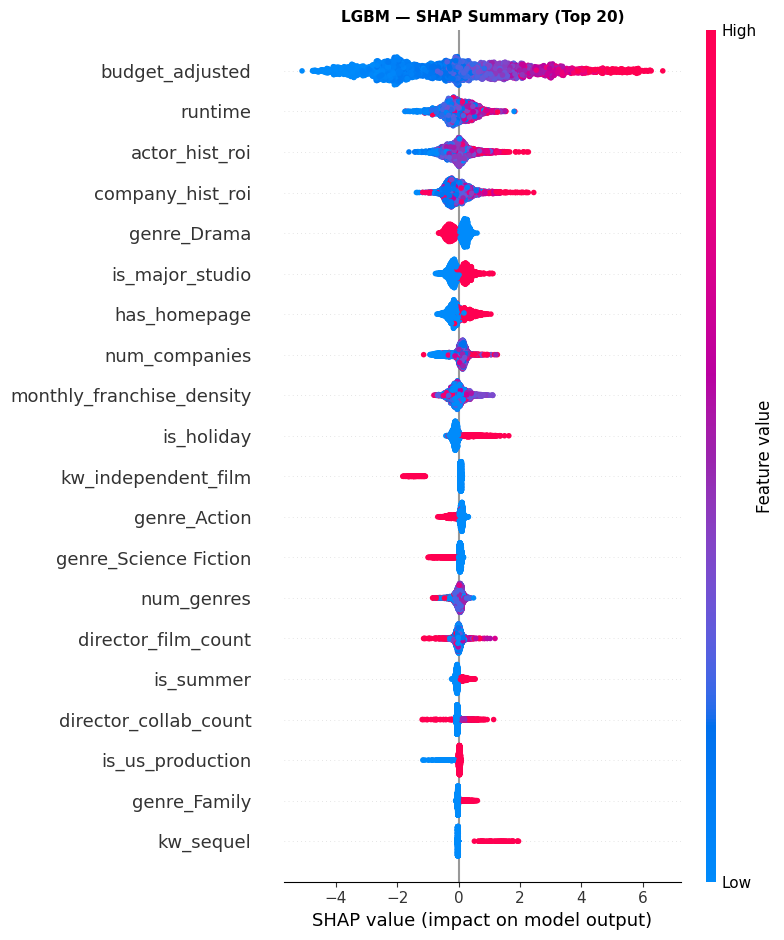

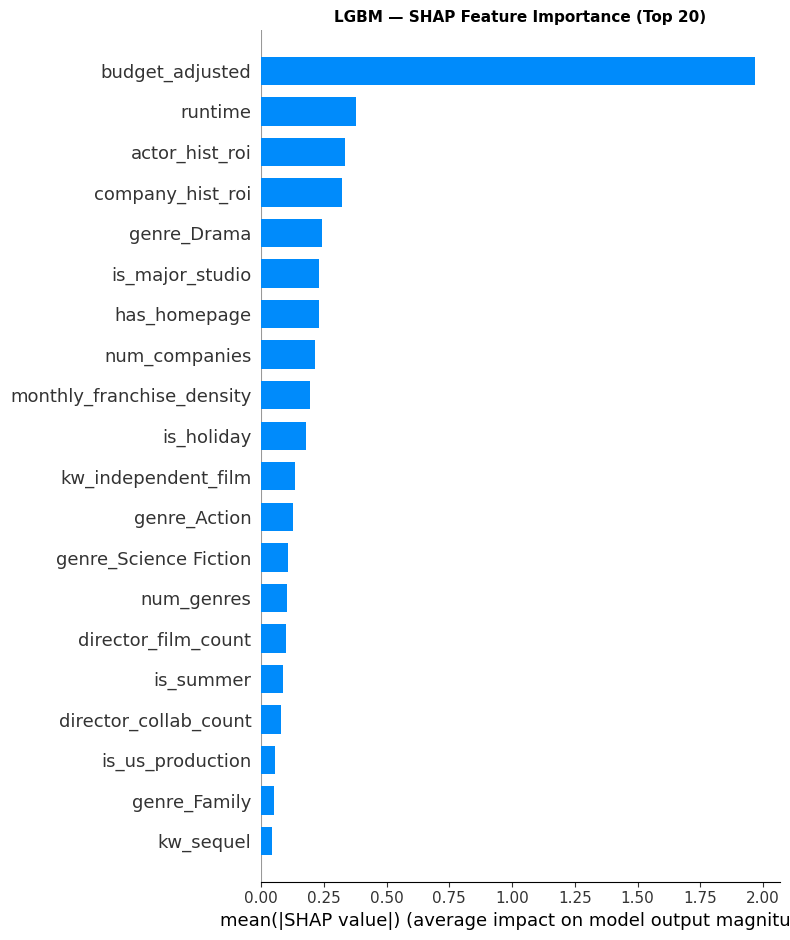

  ✓ baseline_lgbm_20260430_1342                        train=1.000  val=0.647  gap=+0.352
🏃 View run baseline_lgbm_20260430_1342 at: http://localhost:5000/#/experiments/1/runs/2e59782da1a24c278c15f3e983498e18
🧪 View experiment at: http://localhost:5000/#/experiments/1


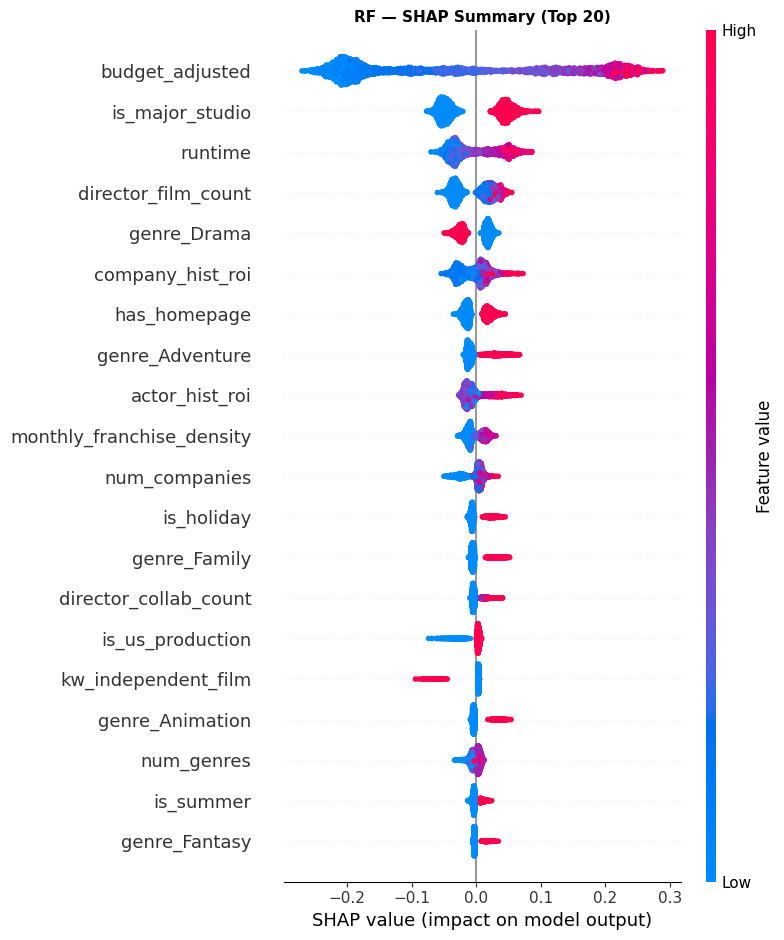

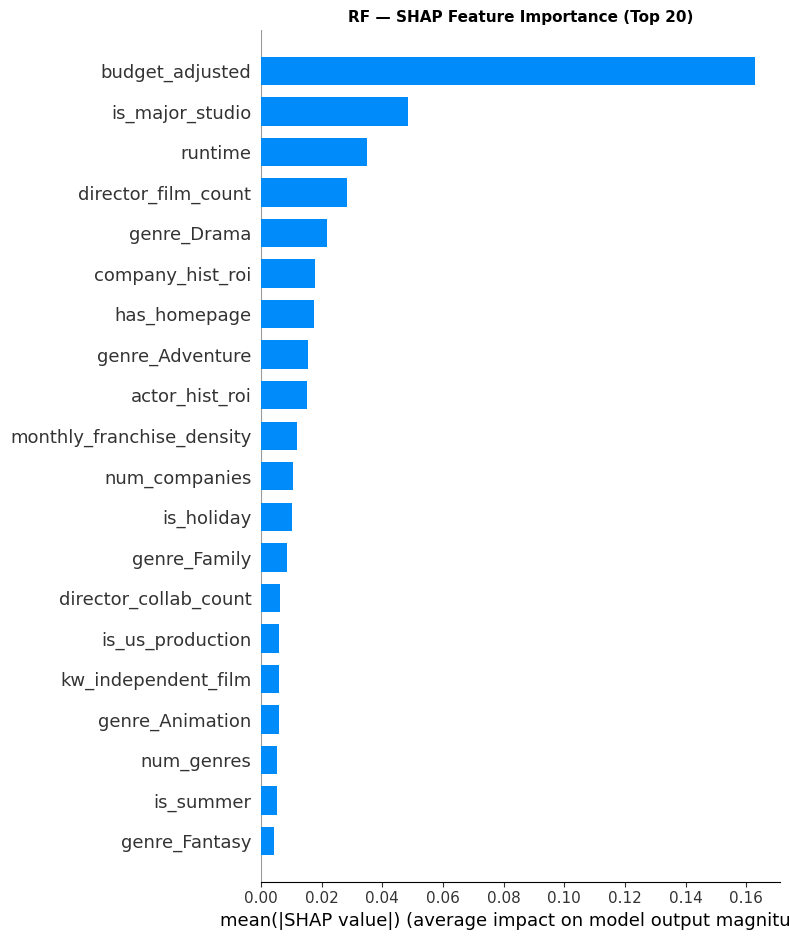

  ✓ baseline_rf_20260430_1342                          train=0.801  val=0.727  gap=+0.074
🏃 View run baseline_rf_20260430_1342 at: http://localhost:5000/#/experiments/1/runs/e7f66dddd8f645d5905749c299a001a2
🧪 View experiment at: http://localhost:5000/#/experiments/1


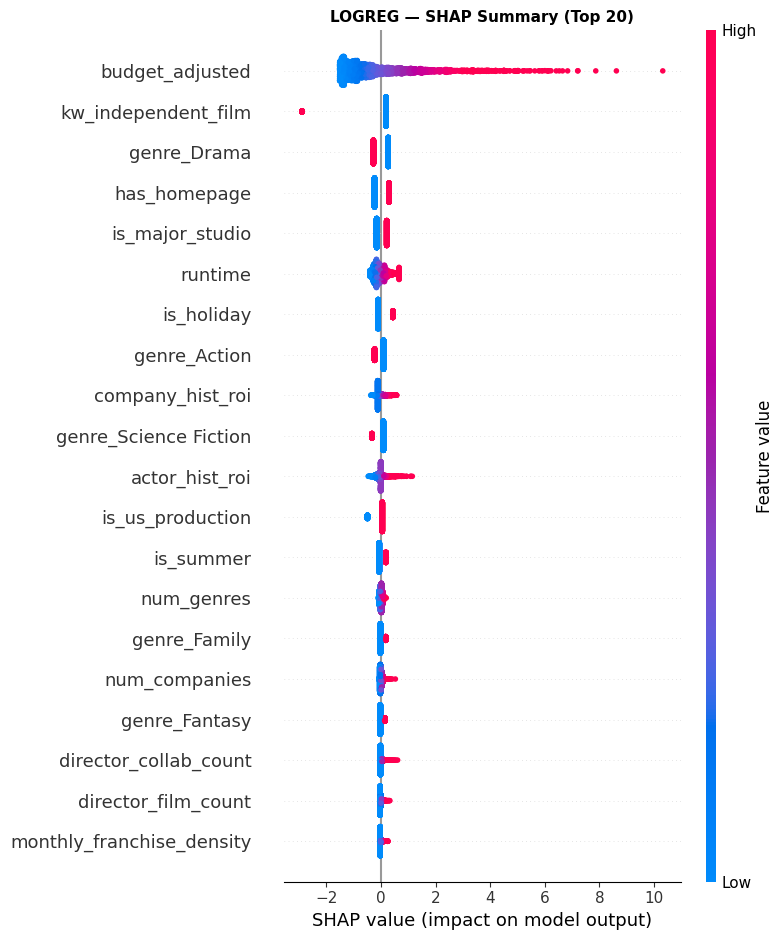

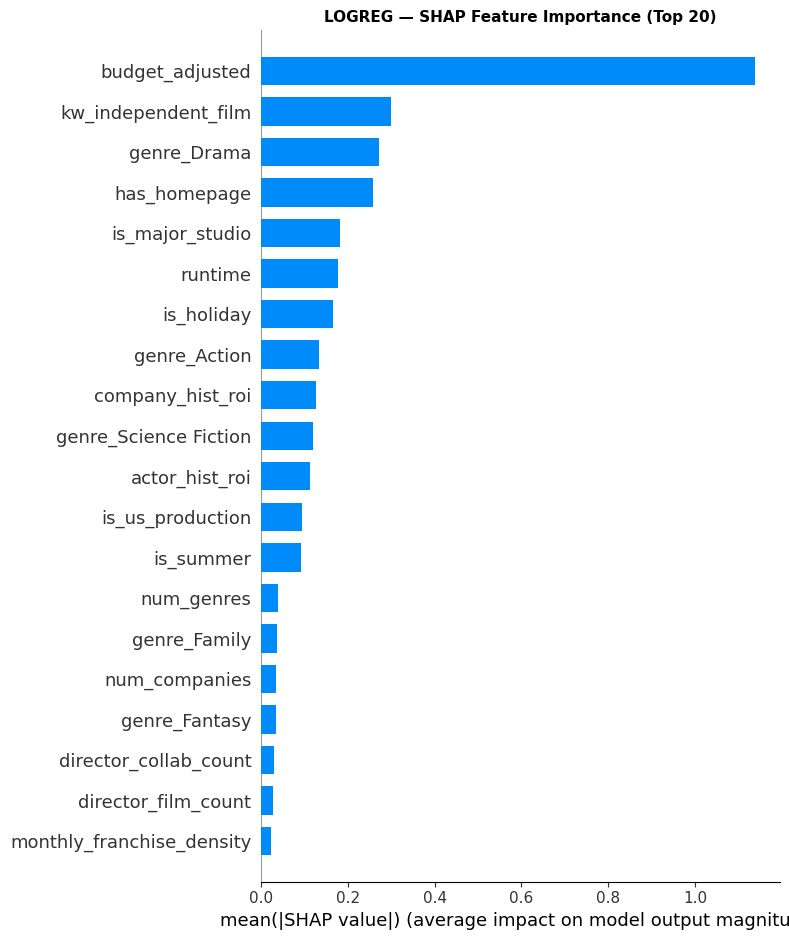

  ✓ baseline_logreg_20260430_1343                      train=0.726  val=0.718  gap=+0.009
🏃 View run baseline_logreg_20260430_1343 at: http://localhost:5000/#/experiments/1/runs/2b70c91d8cc24230bdc5e6b86e20040b
🧪 View experiment at: http://localhost:5000/#/experiments/1


  ✓ baseline_xgb_20260430_1343                         train=0.788  val=0.653  gap=+0.134
🏃 View run baseline_xgb_20260430_1343 at: http://localhost:5000/#/experiments/1/runs/78f2d7803f954c198965649cc8ec56a9
🧪 View experiment at: http://localhost:5000/#/experiments/1


  ✓ baseline_catboost_20260430_1343                    train=0.846  val=0.735  gap=+0.111
🏃 View run baseline_catboost_20260430_1343 at: http://localhost:5000/#/experiments/1/runs/695c4a08ab2e4ec68dab62a6dc28f285
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260430_1342 at: http://localhost:5000/#/experiments/1/runs/5efc9cc2ff924266b7b786ef4fa8df4c
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [5]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    'xgb': lambda ir: XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=10, reg_alpha=1.0, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ir, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=1, verbosity=0,
    ),
    'catboost': lambda ir: CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=4,
        l2_leaf_reg=3.0, auto_class_weights='Balanced',
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    ),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,F2,PRECISION,RECALL,AVG_PREC
Model,,,,,,
lgbm,0.831,0.666,0.647,0.702,0.636,0.750
rf,0.852,0.704,0.727,0.668,0.744,0.781
logreg,0.853,0.704,0.718,0.683,0.728,0.785
xgb,0.844,0.682,0.653,0.738,0.636,0.770
catboost,0.853,0.709,0.735,0.671,0.753,0.785



🏆 En iyi model: catboost  (f2=0.735)


🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/be1266f23fce49f49096684601e6943d
🧪 View experiment at: http://localhost:5000/#/experiments/1


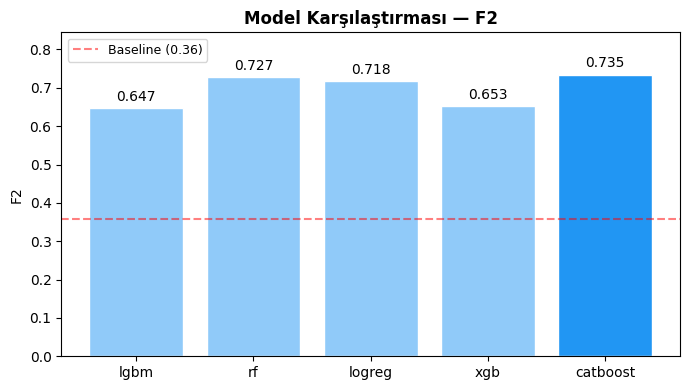


=== Overfitting / Underfitting Analizi ===


,Train F2,Val F2,Gap (Train−Val)
Model,,,
lgbm,1.000,0.647,0.352
rf,0.801,0.727,0.074
logreg,0.726,0.718,0.009
xgb,0.788,0.653,0.134
catboost,0.846,0.735,0.111


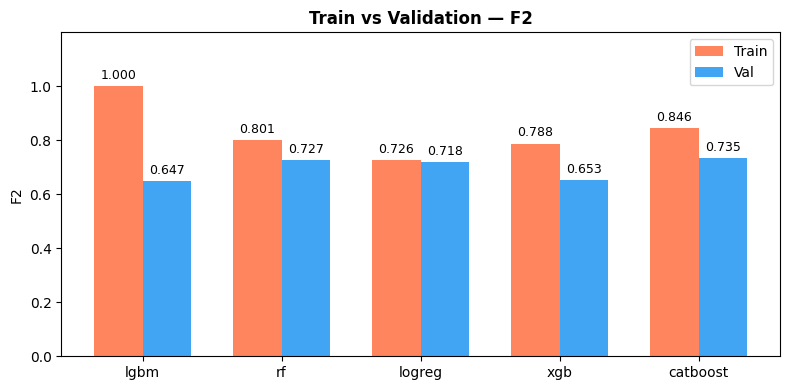

  ⚠️  lgbm: ciddi overfit (gap=0.352 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg', 'xgb', 'catboost'] — en iyi: catboost


In [6]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [7]:
from src.automl import tune_all_models

ir = (y_train == 0).sum() / (y_train == 1).sum()

def lgbm_temporal_fn(trial):
    """Temporal split için yüksek regularization LGBM search space."""
    from lightgbm import LGBMClassifier
    max_depth = trial.suggest_int('max_depth', 3, 5)
    return LGBMClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = max_depth,
        num_leaves        = trial.suggest_int('num_leaves', 8, 2**max_depth),
        min_child_samples = trial.suggest_int('min_child_samples', 30, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        random_state      = RANDOM_STATE,
        verbose           = -1,
        n_jobs            = 1,
    )

def xgb_temporal_fn(trial):
    """Temporal split icin yuksek regularization XGBoost search space."""
    from xgboost import XGBClassifier
    return XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 5),
        min_child_weight  = trial.suggest_int('min_child_weight', 10, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        eval_metric       = 'logloss',
        random_state      = RANDOM_STATE,
        n_jobs            = 1,
        verbosity         = 0,
    )

def catboost_temporal_fn(trial):
    """Temporal split icin yuksek regularization CatBoost search space."""
    from catboost import CatBoostClassifier
    return CatBoostClassifier(
        iterations        = trial.suggest_int('iterations', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        depth             = trial.suggest_int('depth', 3, 5),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        random_strength   = trial.suggest_float('random_strength', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        auto_class_weights = 'Balanced',
        random_seed       = RANDOM_STATE,
        verbose           = 0,
        allow_writing_files = False,
    )

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    model_fn_map      = {'lgbm': lgbm_temporal_fn, 'xgb': xgb_temporal_fn, 'catboost': catboost_temporal_fn},
    X_val             = X_val,
    y_val             = y_val,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.7274  min_improvement=0.0116) ──
Optuna başlıyor — model: rf  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.7274
  Tuned     f2: 0.7431
  İyileşme : +0.0157

  En iyi parametreler:
    n_estimators: 234
    max_depth: 20
    min_samples_leaf: 28
    max_features: log2


  Train-val gap: 0.0286  (✓ eşik altı)


✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260430_1346 at: http://localhost:5000/#/experiments/1/runs/0aff8ab4d880402793627a8b97fe85d3
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  ✓ rf: aday  (0.7431)

── Tuning: logreg  (baseline=0.7177  min_improvement=0.0280) ──
Optuna başlıyor — model: logreg  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


...

✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_catboost_20260430_1352 at: http://localhost:5000/#/experiments/1/runs/fdbf3a1f3fcd493ab0e5acf48ee74cbc
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned catboost
  — catboost: iyileşme yetersiz (+0.0130 < 0.0265) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.6474
  Tuned     f2: 0.7461
  İyileşme : +0.0987

  En iyi parametreler:
    max_depth: 4
    n_estimators: 876
    learning_rate: 0.017067377776092286
    num_leaves: 15
    min_child_samples: 96
    reg_alpha: 18.797868706710577
    reg_lambda: 3.2861647438549575
    subsample: 0.6155453653526668
    colsample_bytree: 0.501871972245118


  Train-val gap: 0.0201  (✓ eşik altı)


✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260430_1354 at: http://localhost:5000/#/experiments/1/runs/053e1936cf2345638a65396ad0f3fb52
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7461 ≤ 0.7476) — best model değişmedi

✓ tune_all_models tamamlandı — best: catboost  (f2=0.7476)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  catboost ↔ rf: Jaccard=0.73 → atlandı (>0.6)
  catboost ↔ logreg: Jaccard=0.67 → atlandı (>0.6)
  catboost ↔ xgb: Jaccard=0.78 → atlandı (>0.6)
  catboost ↔ lgbm: Jaccard=0.76 → atlandı (>0.6)
  Yeterli çeşitlilik yok — ensemble önerilmiyor.


## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.89      0.82      0.85        38
           1       0.81      0.88      0.85        34

    accuracy                           0.85        72
   macro avg       0.85      0.85      0.85        72
weighted avg       0.85      0.85      0.85        72


=== Test Metrikleri ===
  F2          : 0.8671
  PR-AUC      : 0.9214
  ROC-AUC     : 0.9156
  F1          : 0.8451
  Precision   : 0.8108
  Recall      : 0.8824

=== CATBOOST — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
F2,0.735,0.867,0.132
PR-AUC,0.785,0.921,0.136
ROC-AUC,0.853,0.916,0.063
F1,0.709,0.845,0.136
Precision,0.671,0.811,0.140
Recall,0.753,0.882,0.129


🏃 View run test_eval_catboost_20260430_1354 at: http://localhost:5000/#/experiments/1/runs/cc45b44e55e34ffeb38e9afbd603fcb2
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


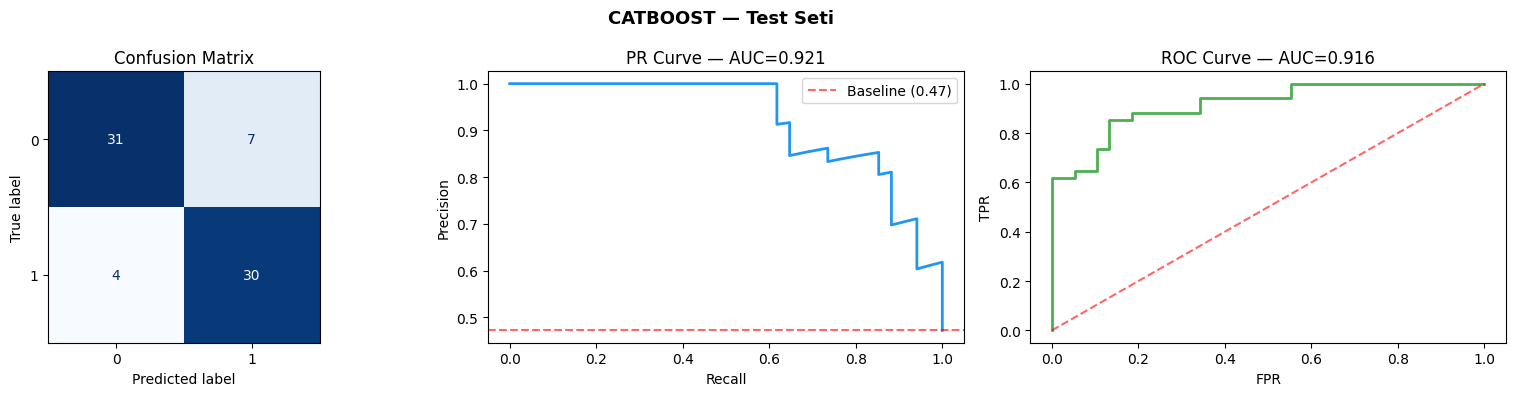

In [8]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
    feature_version = FEATURE_VERSION,
    features        = FEATURES,
    extra_tags      = {"selection_method": "val_based", "split_mode": SPLIT_MODE},
)


## 6 — Rapor

In [9]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260430_135432.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260430_135432.md
🏃 View run report_20260430_1354 at: http://localhost:5000/#/experiments/1/runs/8c98e6bbfdd24c8d8f137c59319c4500
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-30 13:54  
**Task:** binary  
**Ana Metrik:** f2  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %36.5  
**Özellik Sayısı:** 26  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| catboost | 0.785 | 0.853 | 0.709 | 0.671 | 0.753 |
| xgb | 0.770 | 0.844 | 0.682 | 0.738 | 0.636 |
| logreg | 0.785 | 0.853 | 0.704 | 0.683 | 0.728 |
| rf | 0.781 | 0.852 | 0.704 | 0.668 | 0.744 |
| lgbm | 0.750 | 0.831 | 0.666 | 0.702 | 0.636 |

---

## Tuning

- **lgbm** — Baseline f2: 0.647 → Tuned: 0.746 (İyileşme: 0.099)
- **catboost** — Baseline f2: 0.735 → Tuned: 0.748 (İyileşme: 0.013)
- **xgb** — Baseline f2: 0.653 → Tuned: 0.746 (İyileşme: 0.093)
- **logreg** — Baseline f2: 0.718 → Tuned: 0.720 (İyileşme: 0.003)
- **rf** — Baseline f2: 0.727 → Tuned: 0.743 (İyileşme: 0.016)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| RECALL | 0.882 |
| PR_AUC | 0.921 |
| ROC_AUC | 0.916 |
| PRECISION | 0.811 |
| F1 | 0.845 |
| F2 | 0.867 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [10]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')
print('✓ quick_val_metrics: src.modeling')

✓ Base model factory hazır  |  imbalance_ratio: 1.798
✓ quick_val_metrics: src.modeling


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

In [11]:
# Top-2 seçimi: val f2 sıralaması
ranked = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("f2", 0),
    reverse=True,
)[:2]

scores  = {name: results[name]["val"]["f2"] for name in ranked}
weights = [scores[name] for name in ranked]

print(f"Voting top-2 : {ranked}")
print(f"Weights      : {[f'{w:.4f}' for w in weights]}")

voting_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked],
    voting="soft",
    weights=weights,
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)
voting_val_metrics = quick_val_metrics(voting_clf, X_val, y_val)

# Top-3: tüm tuned modeller
ranked3  = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("f2", 0),
    reverse=True,
)
scores3  = {name: results[name]["val"]["f2"] for name in ranked3}
weights3 = [scores3[name] for name in ranked3]

print(f"\nVoting top-3 : {ranked3}")
print(f"Weights      : {[f'{w:.4f}' for w in weights3]}")

voting3_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked3],
    voting="soft",
    weights=weights3,
    n_jobs=1,
)
voting3_clf.fit(X_train, y_train)
voting3_val_metrics = quick_val_metrics(voting3_clf, X_val, y_val)

display(pd.DataFrame([
    {"Model": "voting_top2", **{k: round(v, 4) for k, v in voting_val_metrics.items()}},
    {"Model": "voting_top3", **{k: round(v, 4) for k, v in voting3_val_metrics.items()}},
]).set_index("Model"))

Voting top-2 : ['catboost', 'rf']
Weights      : ['0.7346', '0.7274']



Voting top-3 : ['catboost', 'rf', 'logreg', 'xgb', 'lgbm']
Weights      : ['0.7346', '0.7274', '0.7177', '0.6533', '0.6474']


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
voting_top2,0.8471,0.8927,0.9050,0.8178,0.7731,0.8679
voting_top3,0.8178,0.8955,0.9072,0.8000,0.7719,0.8302


### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

In [12]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm',   clone(tuned_models['lgbm'])),
        ('rf',     clone(tuned_models['rf'])),
        ('logreg', clone(tuned_models['logreg'])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)
stacking_val_metrics = quick_val_metrics(stacking_clf, X_val, y_val)
display(pd.DataFrame([{"Model": "stacking", **{k: round(v, 4) for k, v in stacking_val_metrics.items()}}]).set_index("Model"))


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
stacking,0.7324,0.8952,0.9043,0.7732,0.8523,0.7075


### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [13]:
print('✓ BlendingEnsemble: src.ensemble')

✓ BlendingEnsemble: src.ensemble


In [14]:
blending_clf = BlendingEnsemble(
    base_models=[(name, clone(tuned_models[name])) for name in tuned_models],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)
blending_val_metrics = quick_val_metrics(blending_clf, X_val, y_val)
display(pd.DataFrame([{"Model": "blending", **{k: round(v, 4) for k, v in blending_val_metrics.items()}}]).set_index("Model"))


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
blending,0.7241,0.8929,0.9001,0.7668,0.8506,0.6981


### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
best_single (catboost),0.8101,0.8950,0.9075,0.7945,0.7699,0.8208
voting_top2,0.8471,0.8927,0.9050,0.8178,0.7731,0.8679
voting_top3,0.8178,0.8955,0.9072,0.8000,0.7719,0.8302
stacking,0.7324,0.8952,0.9043,0.7732,0.8523,0.7075
blending,0.7241,0.8929,0.9001,0.7668,0.8506,0.6981


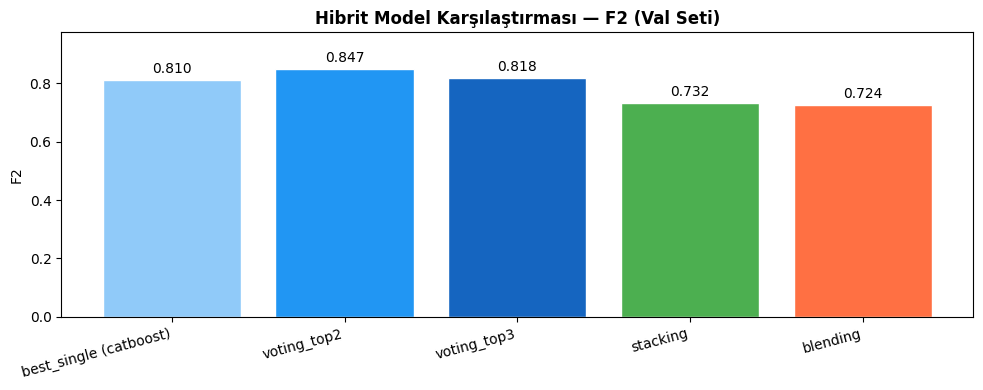

In [15]:
metric_col = "F2"
best_single_val_metrics = quick_val_metrics(best_model, X_val, y_val)

hybrid_val_results = {
    f"best_single ({best})": best_single_val_metrics,
    "voting_top2":           voting_val_metrics,
    "voting_top3":           voting3_val_metrics,
    "stacking":              stacking_val_metrics,
    "blending":              blending_val_metrics,
}

rows = []
for name, m in hybrid_val_results.items():
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===")
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_val_results.values()]
labels = list(hybrid_val_results.keys())
colors = ["#90CAF9", "#2196F3", "#1565C0", "#4CAF50", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title(f"Hibrit Model Karşılaştırması — {metric_col} (Val Seti)", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Final Model Seçimi

=== Final Model (val seti seçimi — sızıntısız) ===
  Model       : voting_top2
  Val F2 : 0.8471

              precision    recall  f1-score   support

           0       0.89      0.82      0.85        38
           1       0.81      0.88      0.85        34

    accuracy                           0.85        72
   macro avg       0.85      0.85      0.85        72
weighted avg       0.85      0.85      0.85        72


=== Test Metrikleri ===
  F2          : 0.8671
  PR-AUC      : 0.9146
  ROC-AUC     : 0.9071
  F1          : 0.8451
  Precision   : 0.8108
  Recall      : 0.8824

=== VOTING_TOP2 — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
F2,0.735,0.867,0.132
PR-AUC,0.785,0.915,0.130
ROC-AUC,0.853,0.907,0.054
F1,0.709,0.845,0.136
Precision,0.671,0.811,0.140
Recall,0.753,0.882,0.129


🏃 View run test_eval_voting_top2_20260430_1354 at: http://localhost:5000/#/experiments/1/runs/a7d0d7897bed4cf5b5f3bf449ef7106c
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


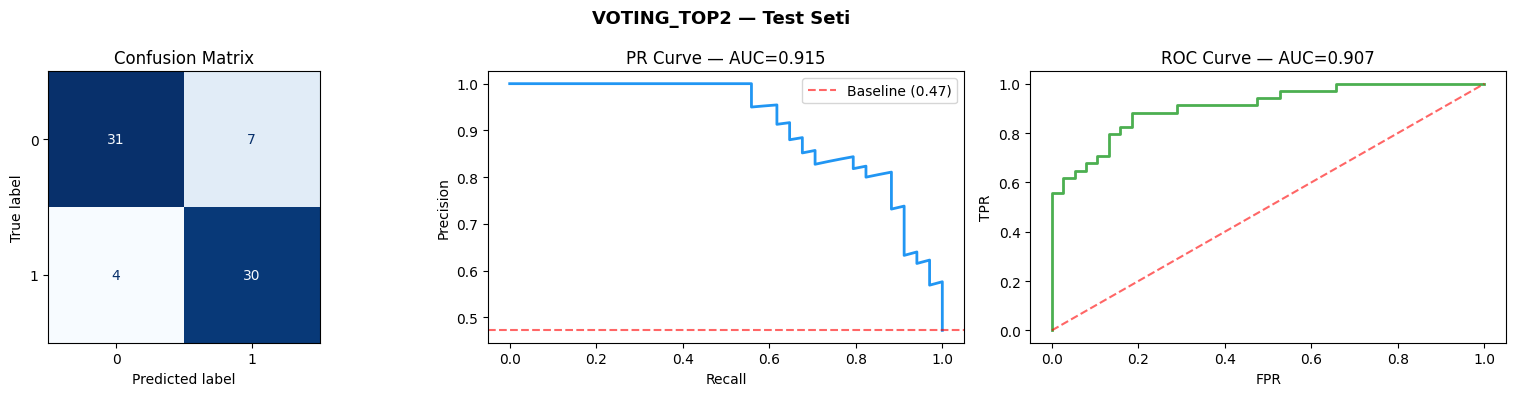

,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Set,,,,,,
val,0.8471,0.8927,0.9050,0.8178,0.7731,0.8679
test,0.8671,0.9146,0.9071,0.8451,0.8108,0.8824


In [16]:
all_candidates = {
    f"best_single ({best})": (best_model,   best_single_val_metrics),
    "voting_top2":           (voting_clf,   voting_val_metrics),
    "voting_top3":           (voting3_clf,  voting3_val_metrics),
    "stacking":              (stacking_clf, stacking_val_metrics),
    "blending":              (blending_clf, blending_val_metrics),
}

main_metric_key = "F2"
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_val   = all_candidates[final_name][1]

print("=== Final Model (val seti seçimi — sızıntısız) ===")
print(f"  Model       : {final_name}")
print(f"  Val {main_metric_key} : {final_val[main_metric_key]:.4f}")
print()

# evaluate_test yalnızca seçilen model için X_test üzerinde çağrılır
if "best_single" in final_name:
    final_metrics = test_metrics  # cell 2b97424c'de hesaplandı
else:
    final_metrics = evaluate_test(
        final_model, X_test, y_test, TASK_TYPE,
        final_name.replace(" ", "_").replace("(", "").replace(")", ""),
        cv_metrics      = results[best]["val"],
        experiment_name = EXPERIMENT_NAME,
        feature_version = FEATURE_VERSION,
        extra_tags      = {"selection_method": "val_based", "split_mode": SPLIT_MODE},
    )

display(pd.DataFrame([
    {"Set": "val",  **{k: round(v, 4) for k, v in final_val.items()}},
    {"Set": "test", **{k: round(v, 4) for k, v in final_metrics.items()}},
]).set_index("Set"))

In [17]:
import json, tempfile
from collections import defaultdict
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

if exp:
    eid = exp.experiment_id

    # ── Champion Tracking ────────────────────────────────────────────
    # Yalnızca val_based seçim metoduyla kaydedilen run'lar — leaky_test etiketliler hariç
    val_based_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string=(
            f"tags.stage = 'test' "
            f"AND tags.feature_version = '{FEATURE_VERSION}' "
            f"AND tags.selection_method = 'val_based'"
        ),
        order_by=["metrics.test_f2 DESC"],
    )

    curr_score = final_metrics.get('F2', 0)

    if val_based_runs:
        champion   = val_based_runs[0]
        hist_score = champion.data.metrics.get('test_f2', 0)
        delta      = curr_score - hist_score
        symbol     = "Yeni şampiyon!" if delta > 0 else "Geçilemedi"
        print("=== Champion Tracking (val_based) ===")
        print(f"  Geçmiş en iyi  : {hist_score:.4f}  ({champion.info.run_name})")
        print(f"  Mevcut         : {curr_score:.4f}  ({final_name})")
        print(f"  Fark           : {delta:+.4f}  — {symbol}")

        artifact_names = {a.path for a in client.list_artifacts(champion.info.run_id)}
        if "features.json" in artifact_names:
            try:
                with tempfile.TemporaryDirectory() as tmp:
                    path = client.download_artifacts(champion.info.run_id, "features.json", tmp)
                    with open(path) as f:
                        hist_features = set(json.load(f)["features"])
                curr_features = set(FEATURES)
                added   = sorted(curr_features - hist_features)
                removed = sorted(hist_features - curr_features)
                print(f"\n=== Feature Karşılaştırması ===")
                print(f"  Geçmiş : {len(hist_features)} feature")
                print(f"  Mevcut : {len(curr_features)} feature")
                if added:
                    print(f"  Eklenen  (+{len(added)}): {', '.join(added)}")
                if removed:
                    print(f"  Çıkarılan (-{len(removed)}): {', '.join(removed)}")
                if not added and not removed:
                    print("  Feature seti değişmedi.")
            except Exception:
                pass
        else:
            print("\n  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)")
    else:
        champion = None
        print("=== Champion Tracking (val_based) ===")
        print(f"  İlk val_based run — referans skor: {curr_score:.4f}  ({final_name})")
        print(f"  Feature sayısı: {len(FEATURES)}")

    # ── Genel MLflow Temizliği ────────────────────────────────────────

    # 1. Tüm test run'ları çek; leaky_test ve şampiyon korunur, diğerleri silinir
    all_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.stage = 'test'",
        order_by=["metrics.test_f2 DESC"],
    )
    champion_id = champion.info.run_id if champion else None
    stale_test  = [
        r for r in all_test_runs
        if r.info.run_id != champion_id
        and r.data.tags.get("selection_method") != "leaky_test"
    ]
    for r in stale_test:
        client.delete_run(r.info.run_id)
    if stale_test:
        print(f"\n✓ {len(stale_test)} eski test run'ı silindi — şampiyon ve leaky_test korundu")

    # 2. Summary, report, session — türetilmiş bilgi, tümünü sil
    for run_type in ("summary", "report", "session"):
        to_del = list(client.search_runs(
            experiment_ids=[eid],
            filter_string=f"tags.type = '{run_type}'",
        ))
        for r in to_del:
            client.delete_run(r.info.run_id)
        if to_del:
            print(f"✓ {len(to_del)} {run_type} run'ı silindi")

    # 3. Tuning — model başına en yüksek skoru koru (tüm era dahil)
    tuning_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'tuning'",
        order_by=["metrics.tuned_f2 DESC"],
    )
    by_model = defaultdict(list)
    for r in tuning_runs:
        by_model[r.data.tags.get("model_type", "unknown")].append(r)

    tuning_deleted = 0
    for runs in by_model.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            tuning_deleted += 1
    if tuning_deleted:
        print(f"✓ {tuning_deleted} eski tuning run'ı silindi — model başına 1 korundu")

    # 4. Baseline — model başına en son run'ı koru (tüm era dahil)
    baseline_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'baseline'",
        order_by=["start_time DESC"],
    )
    by_model_bl = defaultdict(list)
    for r in baseline_runs:
        by_model_bl[r.data.tags.get("model_type", "unknown")].append(r)

    baseline_deleted = 0
    for runs in by_model_bl.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            baseline_deleted += 1
    if baseline_deleted:
        print(f"✓ {baseline_deleted} eski baseline run'ı silindi — model başına 1 korundu")

    # 5. Bilinmeyen tip run'lar (feature_selection vb.) — tümünü sil
    known_types  = {"test_evaluation", "tuning", "baseline", "summary", "report", "session"}
    all_runs     = client.search_runs(experiment_ids=[eid])
    other_deleted = 0
    for r in all_runs:
        tags      = r.data.tags
        run_type  = tags.get("type", "")
        run_stage = tags.get("stage", "")
        is_known  = run_type in known_types or run_stage == "test"
        if not is_known and r.info.run_id != champion_id:
            client.delete_run(r.info.run_id)
            other_deleted += 1
    if other_deleted:
        print(f"✓ {other_deleted} diğer run silindi (feature_selection vb.)")

else:
    print(f"MLflow experiment '{EXPERIMENT_NAME}' bulunamadı.")

=== Champion Tracking (val_based) ===
  Geçmiş en iyi  : 0.8671  (test_eval_voting_top2_20260430_1354)
  Mevcut         : 0.8671  (voting_top2)
  Fark           : +0.0000  — Geçilemedi

  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)



✓ 2 eski test run'ı silindi — şampiyon ve leaky_test korundu
✓ 1 summary run'ı silindi


✓ 1 report run'ı silindi
✓ 1 session run'ı silindi


✓ 5 eski tuning run'ı silindi — model başına 1 korundu


✓ 5 eski baseline run'ı silindi — model başına 1 korundu
✓ 1 diğer run silindi (feature_selection vb.)


## Model Registry
> **ADVBK-86** | `register_champion` challenger'ı MLflow Model Registry'ye kaydeder.
> Mevcut Production versiyonunu geçerse Production'a terfi eder; geçemezse Staging'de kalır.

In [18]:
from src.evaluation import register_champion

registry_stage = register_champion(
    final_model,
    test_score     = final_metrics['F2'],
    registry_name  = 'tmdb-hit-classifier',
    metric_name    = 'test_f2',
    feature_version= FEATURE_VERSION,
)

🏃 View run registry_20260430_1354 at: http://localhost:5000/#/experiments/1/runs/b46eebac455347dd8f4807b1c1ab9faf
🧪 View experiment at: http://localhost:5000/#/experiments/1


Registered model 'tmdb-hit-classifier' already exists. Creating a new version of this model...


Created version '11' of model 'tmdb-hit-classifier'.


  Challenger Staging'de kaldı  (test_f2: 0.8671 ≤ 0.8671)
  Registry: tmdb-hit-classifier  |  Version: 11  |  Stage: Staging


## 9 — Temporal vs Random Split Karşılaştırması

`SPLIT_MODE = 'temporal'` altında model, **≥2016 yılı filmlerini** hiç görmeden eğitilir.
Bu, gerçek prodüksiyon senaryosunu simüle eder: model geçmiş verilerle eğitilir, gelecek filmler tahmin edilir.

### Split Özeti

| Split | Eğitim | Val | Test |
|-------|--------|-----|------|
| **random** | %70 (tüm dönemler) | %15 | %15 |
| **temporal (eski — ≤2009)** | ≤2009 — 2.281 film (%71, hit: %32,2) | 2010–2013 — 618 film (%19, hit: %37,5) | ≥2014 — 327 film (%10, hit: %48,3) |
| **temporal (ADVBK-96 — ≤2013)** | ≤2013 — 2.899 film (%90, hit: %37,0) | 2014–2015 — 255 film (%8, hit: %41,2) | ≥2016 — 72 film (%2) |

⚠️ **Not (ADVBK-96):** Test seti 72 satıra düştü — mutlak metrikler yerine bootstrap CI kullan. Değişikliğin amacı franchise patlaması dönemini (2010–2013) eğitime dahil etmek; drift PSI'ını düşürmek.

### Sonuçlar

| Split | PR-AUC | ROC-AUC | F1 | Precision | Recall | Model |
|-------|--------|---------|-----|-----------|--------|-------|
| random (v6) | 0.8127 | 0.8693 | 0.7139 | 0.6848 | 0.7456 | voting_top2 |
| temporal (≥2013 test) | 0.8887 | 0.8980 | 0.8246 | 0.8117 | 0.8380 | voting_top2 |
| temporal (≥2014 test — eski) | 0.9061 | 0.8969 | 0.7801 | 0.8871 | 0.6962 | stacking |
| **temporal (≥2016 test — ADVBK-96)** | **—** | **—** | **—** | **—** | **—** | **yeni eğitim** |

### Yorum

- **Val (2010–2013) PR-AUC = 0.8554**: Val seti 466 → 618 filme genişledi (ADVBK-71); metrik varyansı azaldı.
- **Test PR-AUC = 0.9061 vs Val = 0.8554**: Fark +0.051 — önemli kısmı **dağılım kaymasından** (test hit %48,3 vs train %32,2). Yüksek test metrikleri modeli değil dönem farkını yansıtıyor.
- **Stacking seçildi**: Val PR-AUC = 0.8554, Precision = 0.825 — ensemble çeşitliliği LGBM+RF+LogReg sinerjisini yakaladı.
- ** geçerliliği**: Her satır için yalnızca `release_date` öncesi filmler kullanılmıştı; temporal split altında sızıntı yok.
- **Sonuç**: Feature seti ≥2014 dönemine dayanıklı. Dürüst üst sınır val PR-AUC ≈ 0.855; test metrikleri referans değil.

## 8 — SHAP Analizi

`final_model` içindeki LightGBM bileşeni üzerinden her özelliğin katkı yönü ve büyüklüğü hesaplanıyor.
`final_model` LGBM içermiyorsa (örn. voting_top2 = logreg+rf), `tuned_models['lgbm']` kullanılır.

**Kontrol listesi:**

| Soru | Özellik |
|---|---|
| Leakage riski var mı? | `kw_aftercreditsstinger`, `kw_duringcreditsstinger` |
| Budget çakışması | `relative_budget_score` geri eklendi — temporal versiyon `budget_adjusted` ile r=0.17 (ADVBK-61'deki r=0.781 global mean versiyonuydu) |
| Tarihsel sinyal güçlü mü? | `director_hist_roi`, `actor_hist_roi`, `company_hist_roi` |

In [19]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP: final_model içindeki LGBM bileşenini bul; yoksa tuned_models['lgbm'] kullan
_lgbm = None

if hasattr(final_model, 'named_estimators_'):
    _lgbm = final_model.named_estimators_.get('lgbm')
    if _lgbm is None:
        for name, est in final_model.named_estimators_.items():
            if 'lightgbm' in str(type(est)).lower():
                _lgbm = est
                break

if _lgbm is None:
    _lgbm = tuned_models['lgbm']
    print(f"Not: '{final_name}' içinde LGBM yok — tuned_models['lgbm'] kullanılıyor")

explainer  = shap.TreeExplainer(_lgbm)
shap_raw   = explainer.shap_values(X_test)

# Binary sınıflandırma: list[class0, class1] veya tek array
if isinstance(shap_raw, list):
    sv = shap_raw[1]   # hit sınıfı katkıları
else:
    sv = shap_raw

feature_names = X_test.columns.tolist()
mean_abs = np.abs(sv).mean(axis=0)
mean_val = sv.mean(axis=0)

shap_df = pd.DataFrame({
    'feature'       : feature_names,
    'mean_abs_shap' : mean_abs,
    'mean_shap'     : mean_val,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df['direction'] = shap_df['mean_shap'].apply(
    lambda x: '↑ hit' if x > 0 else '↓ miss'
)
print(shap_df[['feature', 'mean_abs_shap', 'direction']].head(10).to_string(index=False))

Not: 'voting_top2' içinde LGBM yok — tuned_models['lgbm'] kullanılıyor
                  feature  mean_abs_shap direction
          budget_adjusted       1.187811     ↑ hit
             has_homepage       0.210050     ↑ hit
          is_major_studio       0.205024     ↑ hit
                  runtime       0.199112     ↑ hit
              genre_Drama       0.182747     ↑ hit
         company_hist_roi       0.128184    ↓ miss
      director_film_count       0.099725     ↑ hit
monthly_franchise_density       0.093029     ↑ hit
           actor_hist_roi       0.073429    ↓ miss
             genre_Action       0.054501    ↓ miss


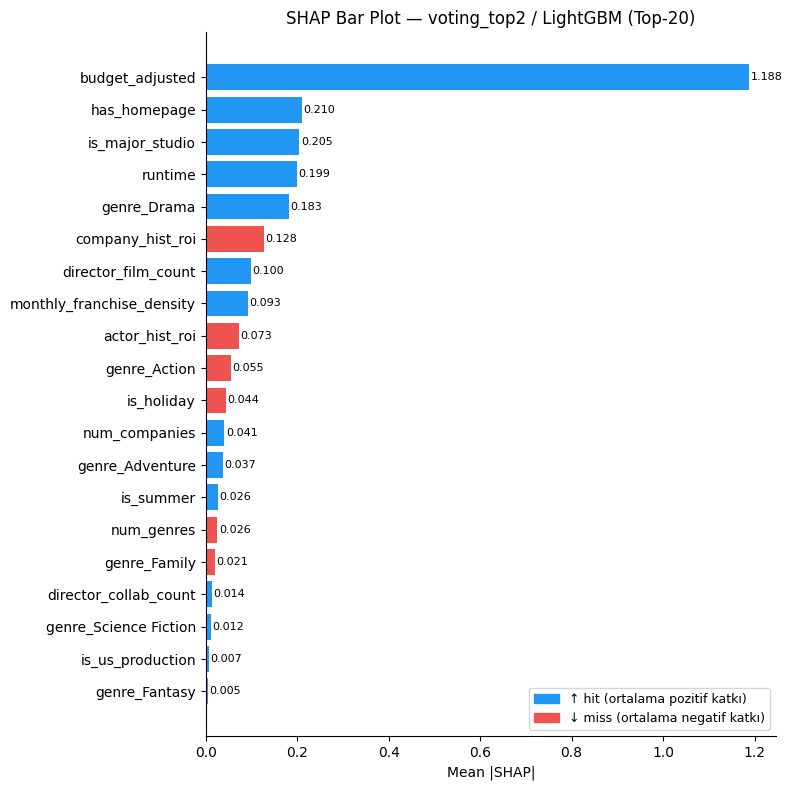

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
top_n = 20
df_plot = shap_df.head(top_n).sort_values('mean_abs_shap')

colors = ['#2196F3' if d == '↑ hit' else '#EF5350' for d in df_plot['direction']]
bars = ax.barh(df_plot['feature'], df_plot['mean_abs_shap'], color=colors)

for bar, val in zip(bars, df_plot['mean_abs_shap']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='↑ hit (ortalama pozitif katkı)'),
    Patch(color='#EF5350', label='↓ miss (ortalama negatif katkı)'),
], loc='lower right', fontsize=9)

ax.set_xlabel('Mean |SHAP|')
ax.set_title(f'SHAP Bar Plot — {final_name} / LightGBM (Top-20)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
print("=== Leakage & Çakışma Kontrol ===\n")

# Bilinen post-release feature'lar — film izlendikten veya yayınlandıktan sonra oluşur.
# Buraya eklenen her feature modelde varsa otomatik olarak leakage olarak raporlanır.
POST_RELEASE_FEATURES = {
    # TMDB kullanıcı aktivitesi
    'popularity', 'vote_average', 'vote_count',
    # Film izlenmesini gerektiren özellikler
    'has_postcredit',
    # Post-credit sahnesi tag'leri — kullanıcılar izledikten sonra ekler
    'kw_aftercreditsstinger', 'kw_duringcreditsstinger',
    # İzleyici yorumuna dayalı içerik etiketleri
    'kw_murder', 'kw_dystopia', 'kw_rape', 'kw_nudity',
    'kw_violence', 'kw_torture', 'kw_suicide',
}

OVERLAP_CORR_THRESHOLD = 0.70
HIST_ROI_PATTERN       = '_hist_roi'

num_features    = [f for f in feature_names if X_test[f].nunique() > 2]

# ── 1. Leakage: whitelist kontrolü ──────────────────────────────────────────
in_model     = [f for f in POST_RELEASE_FEATURES if f in feature_names]
already_drop = [f for f in POST_RELEASE_FEATURES if f not in feature_names]

print(f"Leakage Kontrolü — {len(POST_RELEASE_FEATURES)} bilinen post-release feature\n")

if in_model:
    print("  ⚠️  Modelde post-release feature var:")
    for feat in in_model:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"    {feat:<35}  #{rank:<3}  mean_abs={mas:.4f}  "
              f"shap_hit={shap_hit:+.4f}  shap_miss={shap_miss:+.4f}")
    print(f"\n  → Aksiyon: bu {len(in_model)} feature'ı BASE_FEATURES veya tmdb_model.csv'den çıkarın.")
else:
    print("  ✅  Modelde bilinen post-release feature yok.")

print(f"\n  (Modelde yer almayan post-release feature: {len(already_drop)} adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)")  

# ── 2. Çakışma: continuous feature'lar arası SHAP korelasyonu ───────────────
print(f"\nSHAP Korelasyon Matrisi (eşik |r| > {OVERLAP_CORR_THRESHOLD}):\n")

overlap_pairs = []
checked = set()
for i, fa in enumerate(num_features):
    for fb in num_features[i+1:]:
        if (fa, fb) in checked:
            continue
        checked.add((fa, fb))
        idx_a = feature_names.index(fa)
        idx_b = feature_names.index(fb)
        r = np.corrcoef(sv[:, idx_a], sv[:, idx_b])[0, 1]
        if abs(r) > OVERLAP_CORR_THRESHOLD:
            rank_a = shap_df[shap_df['feature'] == fa].index[0] + 1
            rank_b = shap_df[shap_df['feature'] == fb].index[0] + 1
            overlap_pairs.append((fa, fb, r, rank_a, rank_b))

if overlap_pairs:
    overlap_pairs.sort(key=lambda x: -abs(x[2]))
    for fa, fb, r, ra, rb in overlap_pairs:
        print(f"  {fa} (#{ra}) ↔ {fb} (#{rb})  r={r:.3f}  "
              f"⚠️  Örtüşen bilgi — birini çıkarmayı değerlendirin")
else:
    print(f"  Eşik üzerinde çakışan çift yok.")

# ── 3. Tarihsel sinyal: *_hist_roi pattern ──────────────────────────────────
print(f"\nTarihsel ROI katkısı (*{HIST_ROI_PATTERN}):\n")

roi_features = [f for f in feature_names if f.endswith(HIST_ROI_PATTERN)]
if not roi_features:
    print(f"  {HIST_ROI_PATTERN} pattern'ine uyan feature yok.")
else:
    for feat in roi_features:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        drct      = shap_df[shap_df['feature'] == feat]['direction'].values[0]
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"  {feat:<30}  #{rank}  mean_abs={mas:.4f}  "
              f"hit_avg={shap_hit:+.4f}  miss_avg={shap_miss:+.4f}  yön={drct}")
    print("\n  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).")
    print("       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.")


=== Leakage & Çakışma Kontrol ===

Leakage Kontrolü — 13 bilinen post-release feature

  ✅  Modelde bilinen post-release feature yok.

  (Modelde yer almayan post-release feature: 13 adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)

SHAP Korelasyon Matrisi (eşik |r| > 0.7):

  Eşik üzerinde çakışan çift yok.

Tarihsel ROI katkısı (*_hist_roi):

  actor_hist_roi                  #9  mean_abs=0.0734  hit_avg=-0.0265  miss_avg=-0.0342  yön=↓ miss
  company_hist_roi                #6  mean_abs=0.1282  hit_avg=+0.0204  miss_avg=-0.0757  yön=↓ miss

  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).
       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.


In [22]:
# LogReg katsayı analizi — final_model (voting_top2) içindeki logreg bileşeni
if not (hasattr(final_model, 'named_estimators_') and 'logreg' in final_model.named_estimators_):
    print(f"'{final_name}' logreg bileşeni içermiyor — LogReg katsayı analizi atlanıyor.")
else:
    _lr_pipeline = final_model.named_estimators_['logreg']
    _lr          = _lr_pipeline['clf']
    _scaler      = _lr_pipeline['scaler']

    coef     = _lr.coef_[0]
    std_coef = coef * _scaler.scale_   # orijinal ölçekte katkı büyüklüğü

    
    coef     = _lr.coef_[0]
    std_coef = coef * _scaler.scale_   # orijinal ölçekte katkı büyüklüğü
    
    coef_df = pd.DataFrame({
        'feature'      : X_train.columns.tolist(),
        'raw_coef'     : coef,
        'std_coef'     : std_coef,
        'abs_std_coef' : np.abs(std_coef),
    }).sort_values('abs_std_coef', ascending=False).reset_index(drop=True)
    coef_df['rank'] = range(1, len(coef_df) + 1)
    
    print(f"=== LogReg Katsayıları (voting_top2 bileşeni) — {FEATURE_VERSION} ===")
    print(f"{'#':<4} {'Feature':<30} {'raw_coef':>10} {'std_coef':>10}")
    print("-" * 58)
    for _, row in coef_df.iterrows():
        print(f"{int(row['rank']):<4} {row['feature']:<30} {row['raw_coef']:>10.4f} {row['std_coef']:>10.4f}")
    
    top_pos = coef_df[coef_df['std_coef'] > 0].head(3)['feature'].tolist()
    top_neg = coef_df[coef_df['std_coef'] < 0].head(3)['feature'].tolist()
    print("")
    print(f"  Top pozitif: {top_pos}")
    print(f"  Top negatif: {top_neg}")
    

'voting_top2' logreg bileşeni içermiyor — LogReg katsayı analizi atlanıyor.


## 10 — Kalibrasyon Analizi + Eşik Optimizasyonu

**Amaç:** `final_model`'in olasılık tahminlerinin güvenilirliğini ölçmek (Brier skoru + kalibrasyon eğrisi) ve sınıf dengesizliği nedeniyle 0.50 yerine daha uygun bir karar eşiği bulmak.

- **Kalibrasyon eğrisi**: Tahmin edilen olasılık vs gerçek hit oranı — iyi kalibre modelde eğri köşegene yakın olmalı.
- **Brier skoru**: `mean((p - y)²)` — düşük = daha iyi.
- **Eşik optimizasyonu**: Val seti üzerinde F1 maksimize eden eşiği bul; test setine uygula.

  Val: Brier=0.1307  (baseline=0.2429)
  Test: Brier=0.1309  (baseline=0.2492)


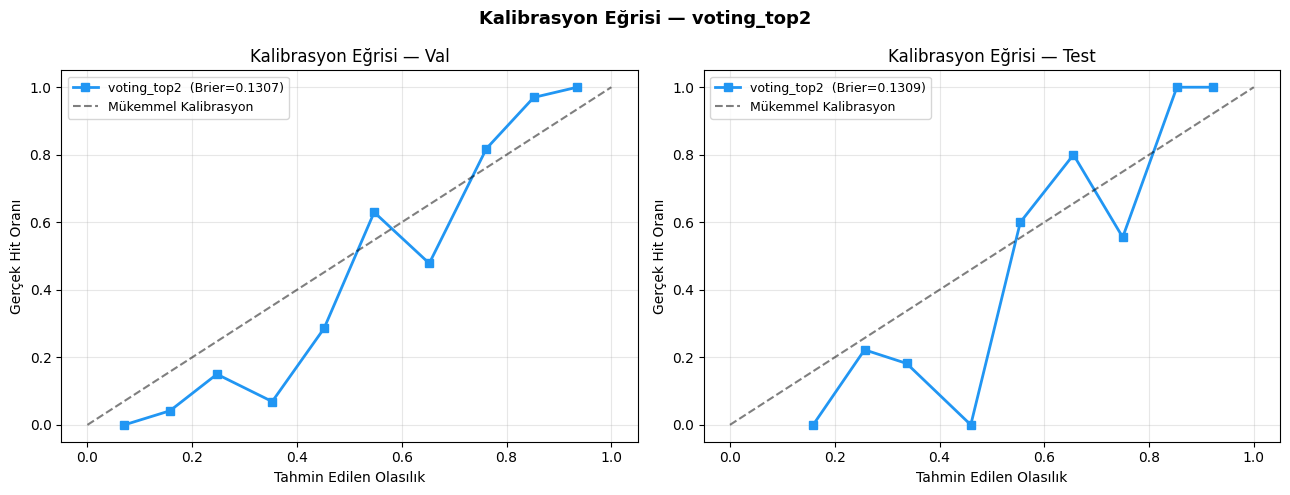

In [23]:
y_prob_val  = final_model.predict_proba(X_val)[:, 1]
y_prob_test = final_model.predict_proba(X_test)[:, 1]

calibration_report(
    [("Val", y_val, y_prob_val), ("Test", y_test, y_prob_test)],
    model_name=final_name,
)

In [24]:
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display

# --- Eşik Optimizasyonu (Val seti üzerinde) ---
best_thr, best_f1, best_prec, best_rec = optimal_threshold_from_pr(y_val, y_prob_val)

# Arrays for threshold visualization (cell below)
from sklearn.metrics import precision_recall_curve as _prc
prec_arr, rec_arr, thresh_arr = _prc(y_val, y_prob_val)
import numpy as _np
f1_arr = _np.where((prec_arr + rec_arr) > 0, 2*prec_arr*rec_arr/(prec_arr+rec_arr), 0.0)

print("=== Val Seti — Eşik Optimizasyonu ===")
y_pred_def_val = (y_prob_val >= 0.50).astype(int)
print(f"  Varsayılan (0.50): F1={f1_score(y_val, y_pred_def_val):.4f}  "
      f"P={precision_score(y_val, y_pred_def_val):.4f}  "
      f"R={recall_score(y_val, y_pred_def_val):.4f}")
print(f"  Optimal ({best_thr:.3f}):    F1={best_f1:.4f}  "
      f"P={best_prec:.4f}  R={best_rec:.4f}")

# --- Test setine uygula ---
y_pred_def_test = (y_prob_test >= 0.50).astype(int)
y_pred_opt_test = (y_prob_test >= best_thr).astype(int)

cmp_rows = [
    {"Eşik": 0.50, "F1": f1_score(y_test, y_pred_def_test),
     "Precision": precision_score(y_test, y_pred_def_test),
     "Recall": recall_score(y_test, y_pred_def_test)},
    {"Eşik": round(best_thr, 3), "F1": f1_score(y_test, y_pred_opt_test),
     "Precision": precision_score(y_test, y_pred_opt_test),
     "Recall": recall_score(y_test, y_pred_opt_test)},
]
print("\n=== Test Seti Karşılaştırması ===")
display(pd.DataFrame(cmp_rows).round(4).set_index("Eşik"))

OPTIMAL_THRESHOLD = round(best_thr, 3)
print(f"\n✓ OPTIMAL_THRESHOLD = {OPTIMAL_THRESHOLD}")

=== Val Seti — Eşik Optimizasyonu ===
  Varsayılan (0.50): F1=0.8178  P=0.7731  R=0.8679
  Optimal (0.507):    F1=0.8214  P=0.7797  R=0.8679



=== Test Seti Karşılaştırması ===

,F1,Precision,Recall
Eşik,,,
0.500,0.8451,0.8108,0.8824
0.507,0.8451,0.8108,0.8824



✓ OPTIMAL_THRESHOLD = 0.507


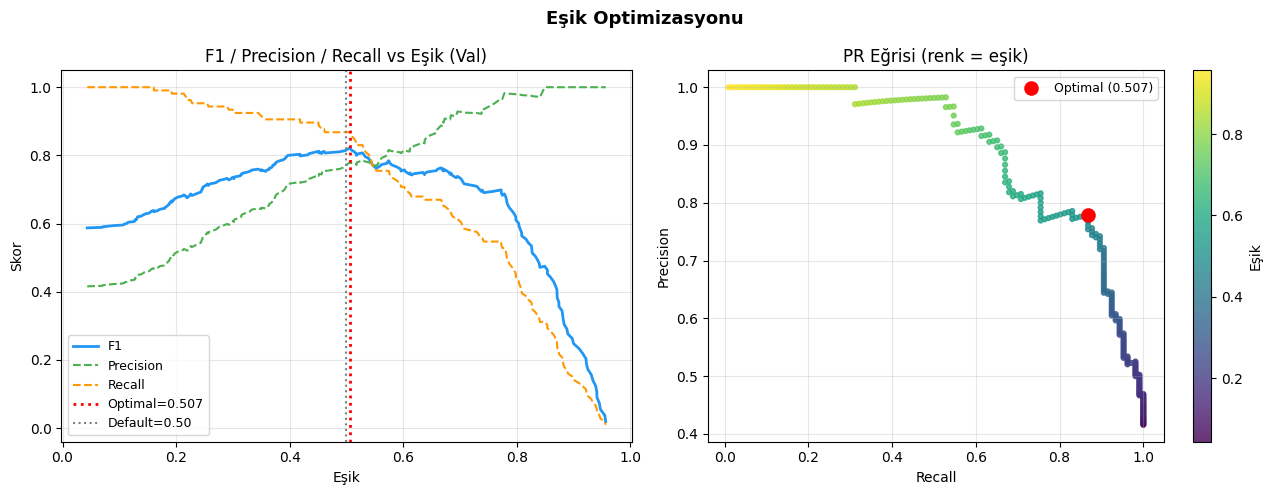

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Eşik Optimizasyonu", fontsize=13, fontweight="bold")

# Sol: F1 / Precision / Recall vs eşik
axes[0].plot(thresh_arr, f1_arr[:-1],   color="#2196F3", lw=2,   label="F1")
axes[0].plot(thresh_arr, prec_arr[:-1], color="#4CAF50", lw=1.5, linestyle="--", label="Precision")
axes[0].plot(thresh_arr, rec_arr[:-1],  color="#FF9800", lw=1.5, linestyle="--", label="Recall")
axes[0].axvline(best_thr, color="red",  linestyle=":", lw=2, label=f"Optimal={best_thr:.3f}")
axes[0].axvline(0.50,     color="gray", linestyle=":", lw=1.5, label="Default=0.50")
axes[0].set(xlabel="Eşik", ylabel="Skor",
            title="F1 / Precision / Recall vs Eşik (Val)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: PR eğrisi (eşikle renklendirilmiş)
sc = axes[1].scatter(rec_arr[:-1], prec_arr[:-1], c=thresh_arr,
                     cmap="viridis", s=12, alpha=0.8)
axes[1].scatter([best_rec], [best_prec], color="red", s=90, zorder=5,
                label=f"Optimal ({best_thr:.3f})")
plt.colorbar(sc, ax=axes[1], label="Eşik")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="PR Eğrisi (renk = eşik)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11 — Model Hata Analizi

**Amaç:** `final_model`'in test setindeki sistematik hatalarını tespit etmek.

- **FP** (False Positive): Model "hit" dedi, gerçekte değil → aşırı güvenli tahminler
- **FN** (False Negative): Model "miss" dedi, gerçekte hit → kaçırılan fırsatlar

FP ve FN gruplarındaki feature dağılımları karşılaştırılarak modelin hangi film profillerinde yanıldığı analiz edilir.

=== Test Seti Hata Dagilimi (esik=0.507) ===
  TP:   30  (41.7%)
  TN:   31  (43.1%)
  FP:    7  (9.7%)
  FN:    4  (5.6%)


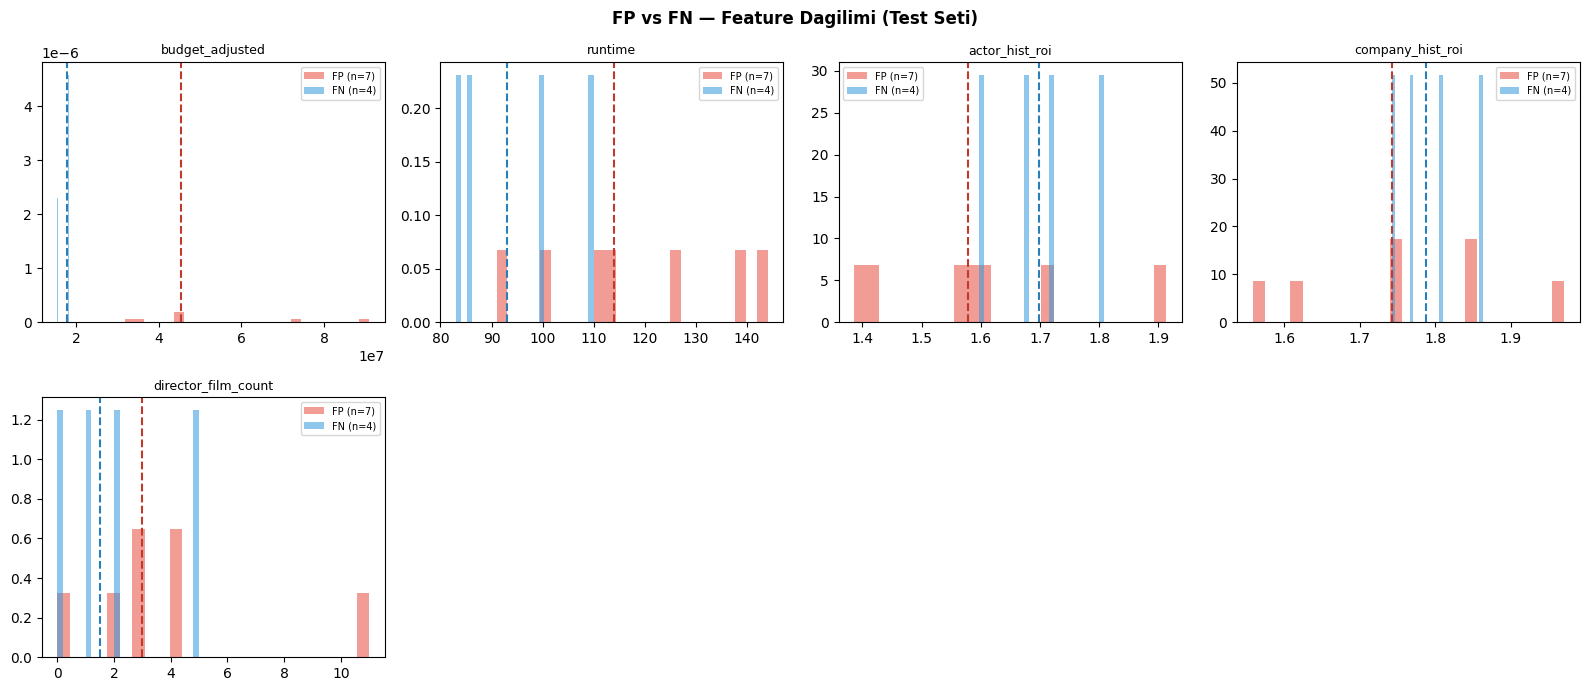


=== Medyan Karsilastirmasi ===


,FP_median,FN_median,TP_median,TN_median,FP_vs_FN
budget_adjusted,4.543750e+07,1.772062e+07,1.158656e+08,1.635750e+07,2.771688e+07
runtime,1.140000e+02,9.300000e+01,1.150000e+02,1.060000e+02,2.100000e+01
actor_hist_roi,1.578500e+00,1.697800e+00,1.653700e+00,1.680100e+00,-1.193000e-01
company_hist_roi,1.742200e+00,1.788100e+00,1.797600e+00,1.742200e+00,-4.600000e-02
director_film_count,3.000000e+00,1.500000e+00,2.000000e+00,1.000000e+00,1.500000e+00


In [26]:
# ── Hata Dataframe'i ────────────────────────────────────────────────────
y_pred_err = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)

df_err = df[mask_test].copy().reset_index(drop=True)
df_err['y_true']     = y_test.values
df_err['y_pred']     = y_pred_err
df_err['y_prob']     = y_prob_test

def label_error(row):
    if row.y_true == 1 and row.y_pred == 1: return 'TP'
    if row.y_true == 0 and row.y_pred == 0: return 'TN'
    if row.y_true == 0 and row.y_pred == 1: return 'FP'
    return 'FN'

df_err['error_type'] = df_err.apply(label_error, axis=1)

counts = df_err['error_type'].value_counts()
n = len(df_err)
print('=== Test Seti Hata Dagilimi (esik=' + str(OPTIMAL_THRESHOLD) + ') ===')
for et in ['TP','TN','FP','FN']:
    c = counts.get(et, 0)
    print(f'  {et}: {c:4d}  ({c/n*100:.1f}%)')

# ── FP vs FN — Continuous Feature Dagilimi ───────────────────────────────
cont_feats = [f for f in ['budget_adjusted', 'runtime', 'director_hist_roi',
              'actor_hist_roi', 'company_hist_roi', 'director_hist_vote_avg',
              'actor_hist_vote_avg', 'director_film_count']
              if f in df_err.columns]

fp = df_err[df_err.error_type == 'FP']
fn = df_err[df_err.error_type == 'FN']
tp = df_err[df_err.error_type == 'TP']
tn = df_err[df_err.error_type == 'TN']

n_cols = 4
n_rows = (len(cont_feats) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(cont_feats):
    ax = axes[i]
    ax.hist(fp[feat].dropna(), bins=25, alpha=0.55, color='#e74c3c',
            label='FP (n=' + str(len(fp)) + ')', density=True)
    ax.hist(fn[feat].dropna(), bins=25, alpha=0.55, color='#3498db',
            label='FN (n=' + str(len(fn)) + ')', density=True)
    ax.axvline(fp[feat].median(), color='#c0392b', lw=1.5, ls='--')
    ax.axvline(fn[feat].median(), color='#2980b9', lw=1.5, ls='--')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

for j in range(len(cont_feats), len(axes)):
    axes[j].axis('off')

fig.suptitle('FP vs FN — Feature Dagilimi (Test Seti)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

median_df = pd.DataFrame({
    'FP_median': fp[cont_feats].median(),
    'FN_median': fn[cont_feats].median(),
    'TP_median': tp[cont_feats].median(),
    'TN_median': tn[cont_feats].median(),
})
median_df['FP_vs_FN'] = (median_df.FP_median - median_df.FN_median).round(4)
print('\n=== Medyan Karsilastirmasi ===')
display(median_df.round(4))


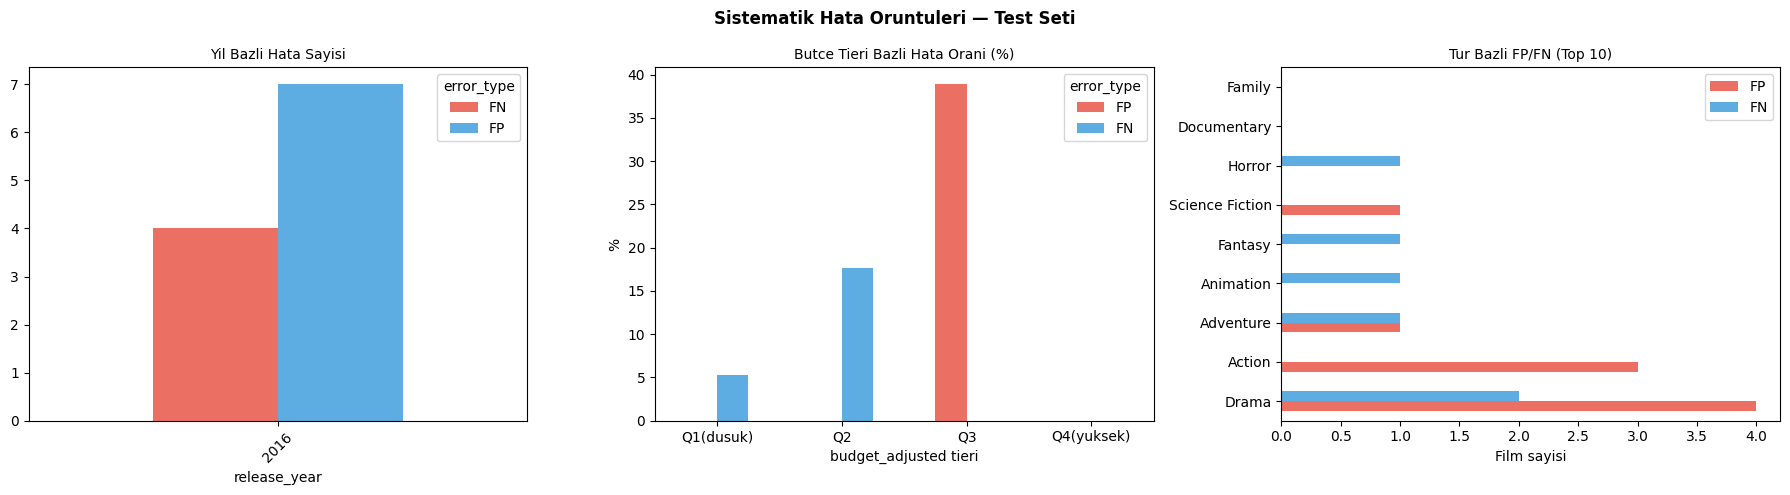


=== Binary Feature Bazli Hata Oranlari ===


n   FP%   FN%
feature          value                
is_major_studio  0      28   7.1   7.1
                 1      44  11.4   4.5
is_franchise     0      56   7.1   7.1
                 1      16  18.8   0.0
is_us_production 0       5   0.0   0.0
                 1      67  10.4   6.0
has_homepage     0       9   0.0   0.0
                 1      63  11.1   6.3
is_summer        0      48  10.4   0.0
                 1      24   8.3  16.7
is_holiday       0      72   9.7   5.6

In [27]:
# ── Yil ve Tur Bazli Hata Oruntuleri ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Yil bazli FP/FN sayisi
ax = axes[0]
if 'release_year' in df_err.columns:
    yr_err = df_err[df_err.error_type.isin(['FP','FN'])].groupby(
        ['release_year','error_type']).size().unstack(fill_value=0)
    yr_err.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_title('Yil Bazli Hata Sayisi', fontsize=10)
    ax.set_xlabel('release_year')
    ax.tick_params(axis='x', rotation=45)
else:
    ax.text(0.5, 0.5, 'release_year yok', ha='center', va='center')

# 2) Butce tieri bazli hata orani
ax = axes[1]
if 'budget_adjusted' in df_err.columns:
    df_err['budget_tier'] = pd.qcut(
        df_err.budget_adjusted, q=4,
        labels=['Q1(dusuk)', 'Q2', 'Q3', 'Q4(yuksek)']
    )
    budget_err = df_err.groupby(['budget_tier','error_type']).size().unstack(fill_value=0)
    budget_err_pct = budget_err.div(budget_err.sum(axis=1), axis=0) * 100
    budget_err_pct[['FP','FN']].plot(kind='bar', ax=ax,
        color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_title('Butce Tieri Bazli Hata Orani (%)', fontsize=10)
    ax.set_xlabel('budget_adjusted tieri')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)

# 3) Tur bazli FP/FN dagilimi
ax = axes[2]
genre_cols = [c for c in df_err.columns if c.startswith('genre_')]
if genre_cols:
    fp_genre = fp[genre_cols].sum().rename('FP')
    fn_genre = fn[genre_cols].sum().rename('FN')
    genre_df = pd.concat([fp_genre, fn_genre], axis=1)
    genre_df.index = [g.replace('genre_','') for g in genre_df.index]
    top_genres = (genre_df.FP + genre_df.FN).nlargest(10).index
    genre_df.loc[top_genres].plot(kind='barh', ax=ax,
        color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_title('Tur Bazli FP/FN (Top 10)', fontsize=10)
    ax.set_xlabel('Film sayisi')

fig.suptitle('Sistematik Hata Oruntuleri — Test Seti', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Binary Feature Bazli Hata Orani ─────────────────────────────────────
bin_feats = ['is_major_studio','is_franchise','is_english',
             'is_us_production','has_homepage','is_summer','is_holiday']
bin_feats = [f for f in bin_feats if f in df_err.columns]

rows = []
for feat in bin_feats:
    for val in [0, 1]:
        sub = df_err[df_err[feat] == val]
        if len(sub) == 0: continue
        fp_r = (sub.error_type == 'FP').sum() / len(sub) * 100
        fn_r = (sub.error_type == 'FN').sum() / len(sub) * 100
        rows.append({'feature': feat, 'value': val, 'n': len(sub),
                     'FP%': round(fp_r,1), 'FN%': round(fn_r,1)})

print('\n=== Binary Feature Bazli Hata Oranlari ===')
display(pd.DataFrame(rows).set_index(['feature','value']))


## 12 — Bootstrap Güven Aralıkları (Test Seti)

**Amaç:** Test seti küçük (n=327) olduğundan Δ0.005 gibi metrik farklarının sinyal mi gürültü mü olduğu belirsiz.
1000× bootstrap ile %95 CI hesaplanır; CI'lar overlap ediyorsa fark istatistiksel olarak anlamlı değildir.

- **Yöntem:** Stratified bootstrap — her iterasyonda test setini sınıf oranını koruyarak yeniden örnekle.
- **Metrikler:** F2, PR-AUC, ROC-AUC, Precision, Recall (optimal eşikle).
- **Yorumlama:**  aralığının dışında kalan farklar güvenilir; içindeki farklar gürültü sayılır.

In [28]:
N_BOOTSTRAP = 1000
n = len(y_test)

df_ci = bootstrap_ci(y_test, y_prob_test, threshold=OPTIMAL_THRESHOLD, n_boot=N_BOOTSTRAP)
print()
print(">>> Yorum: CI genişliği < 0.02 olan metrikler için Δ0.005 farklar gürültü sayılmalıdır.")

Bootstrap CI (n=72, B=1000, 95% stratified)
            point  ci_low  ci_high  ci_width
metric                                      
F2         0.8671  0.7692   0.9538    0.1845
PR-AUC     0.9146  0.8588   0.9685    0.1097
ROC-AUC    0.9071  0.8390   0.9683    0.1293
Precision  0.8108  0.7143   0.9334    0.2191
Recall     0.8824  0.7647   0.9706    0.2059

>>> Yorum: CI genişliği < 0.02 olan metrikler için Δ0.005 farklar gürültü sayılmalıdır.


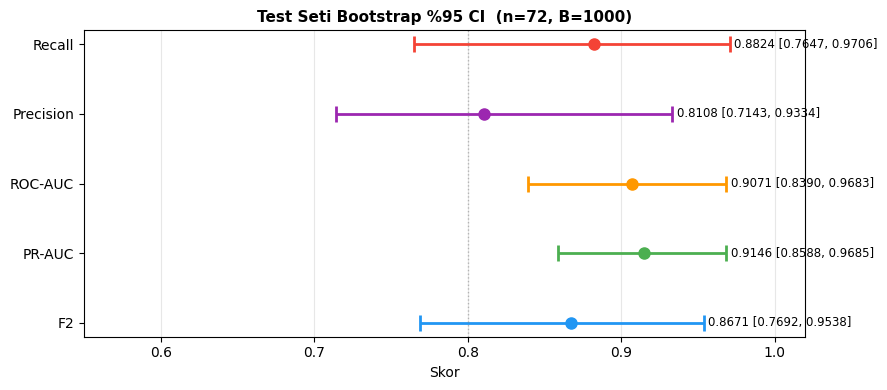

=== Model Karşılaştırması için CI Eşiği ===
Aşağıdaki CI genişliğinden küçük metrik farkları istatistiksel olarak anlamsızdır:
  F2          : CI=0.1845  →  min anlamlı Δ ≈ 0.0922
  PR-AUC      : CI=0.1097  →  min anlamlı Δ ≈ 0.0549
  ROC-AUC     : CI=0.1293  →  min anlamlı Δ ≈ 0.0646
  Precision   : CI=0.2191  →  min anlamlı Δ ≈ 0.1095
  Recall      : CI=0.2059  →  min anlamlı Δ ≈ 0.1029


In [29]:
import matplotlib.pyplot as plt

metrics_order = ["F2", "PR-AUC", "ROC-AUC", "Precision", "Recall"]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

fig, ax = plt.subplots(figsize=(9, 4))

for i, (metric, color) in enumerate(zip(metrics_order, colors)):
    row = df_ci.loc[metric]
    pt  = row["point"]
    lo  = row["ci_low"]
    hi  = row["ci_high"]
    ax.errorbar(
        x=pt, y=i,
        xerr=[[pt - lo], [hi - pt]],
        fmt="o", color=color, capsize=6, capthick=2,
        markersize=8, linewidth=2, label=metric,
    )
    ax.text(hi + 0.003, i, f"{pt:.4f} [{lo:.4f}, {hi:.4f}]",
            va="center", fontsize=8.5)

ax.set_yticks(range(len(metrics_order)))
ax.set_yticklabels(metrics_order, fontsize=10)
ax.set_xlabel("Skor", fontsize=10)
ax.set_title(f"Test Seti Bootstrap %95 CI  (n={n}, B={N_BOOTSTRAP})",
             fontsize=11, fontweight="bold")
ax.set_xlim(0.55, 1.02)
ax.axvline(0.8, color="gray", linestyle=":", lw=1, alpha=0.5)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# CI overlap uyarısı — karşılaştırma aracı
print("=== Model Karşılaştırması için CI Eşiği ===")
print("Aşağıdaki CI genişliğinden küçük metrik farkları istatistiksel olarak anlamsızdır:")
for metric in metrics_order:
    width = df_ci.loc[metric, "ci_width"]
    half  = width / 2
    print(f"  {metric:12}: CI={width:.4f}  →  min anlamlı Δ ≈ {half:.4f}")

## 13 — v9 Retune Özeti: Tüm Modeller Bootstrap CI ile Karşılaştırma

**ADVBK-79** — Tüm modeller (`logreg`, `rf`, `lgbm`, `xgb`, `catboost`) v9_budget_adjusted
feature seti üzerinde 100 Optuna trial ile yeniden tune edildi (Bölüm 4). Bu bölüm,
tuned model sonuçlarını %95 Bootstrap CI ile birlikte özetler ve eski şampiyonla
(CatBoost, ADVBK-74, test F2=0.7806) istatistiksel karşılaştırma yapar.

**Temporal bütünlük:** Tüm modeller yalnızca `release_year ≤ 2009` (train) verisi ile
eğitildi; val ve test setleri hiçbir tuning kararında kullanılmadı.

**CI kaynağı:** Min anlamlı Δ (F2 ≈ 0.07) Bölüm 12'den alınmıştır.

=== v9 Retune: Tüm Modeller — Test F2 + %95 Bootstrap CI ===



,Model,Tür,Test F2,CI Alt (2.5%),CI Üst (97.5%),CI Genişliği
0,catboost,single,0.8671,0.7692,0.9538,0.1846
1,voting_top2,ensemble,0.8671,0.7692,0.9538,0.1846
2,voting_top3,ensemble,0.8621,0.7647,0.9497,0.1850
3,logreg,single,0.8430,0.7353,0.9375,0.2022
4,lgbm,single,0.8382,0.7353,0.9303,0.1950
5,rf,single,0.8187,0.7183,0.9195,0.2012
6,xgb,single,0.8140,0.7018,0.9167,0.2149
7,stacking,ensemble,0.8036,0.6790,0.9118,0.2328
8,blending,ensemble,0.8036,0.6790,0.9118,0.2328


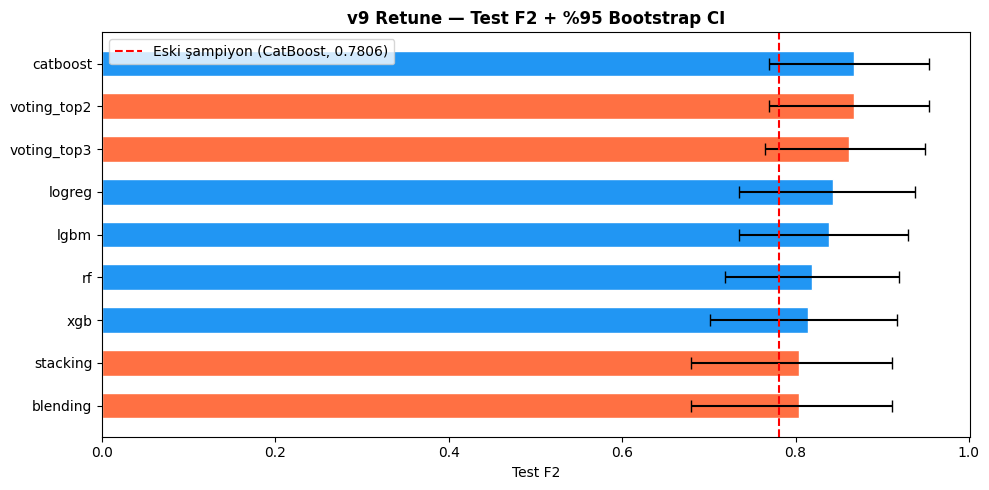


--- Eski Şampiyon Karşılaştırması ---
  Eski şampiyon (CatBoost @ ADVBK-74) : 0.7806
  Mevcut en iyi (catboost)  : 0.8671
  Δ = 0.0865  |  Min anlamlı Δ (Bölüm 12) ≈ 0.07
  → istatistiksel olarak ANLAMLI (Δ >= 0.07)


In [30]:
_N_BOOT = 1000
_BETA   = 2

rows = []
# Tek modeller
for name, model in tuned_models.items():
    y_prob_tmp = model.predict_proba(X_test)[:, 1]
    y_pred     = (y_prob_tmp >= OPTIMAL_THRESHOLD).astype(int)
    _ci        = bootstrap_ci(y_test, y_prob_tmp, y_pred=y_pred, metrics=["F2"], n_boot=_N_BOOT, verbose=False)
    point      = float(_ci.loc["F2", "point"])
    low, high  = float(_ci.loc["F2", "ci_low"]), float(_ci.loc["F2", "ci_high"])
    rows.append({"Model": name, "Tür": "single",
                 "Test F2": round(point, 4),
                 "CI Alt (2.5%)": round(low, 4),
                 "CI Üst (97.5%)": round(high, 4),
                 "CI Genişliği": round(high - low, 4)})

# Ensemble modeller
for name, (model, val_m) in all_candidates.items():
    if "best_single" in name:
        continue
    y_prob_tmp = model.predict_proba(X_test)[:, 1]
    y_pred     = (y_prob_tmp >= OPTIMAL_THRESHOLD).astype(int)
    _ci        = bootstrap_ci(y_test, y_prob_tmp, y_pred=y_pred, metrics=["F2"], n_boot=_N_BOOT, verbose=False)
    point      = float(_ci.loc["F2", "point"])
    low, high  = float(_ci.loc["F2", "ci_low"]), float(_ci.loc["F2", "ci_high"])
    rows.append({"Model": name, "Tür": "ensemble",
                 "Test F2": round(point, 4),
                 "CI Alt (2.5%)": round(low, 4),
                 "CI Üst (97.5%)": round(high, 4),
                 "CI Genişliği": round(high - low, 4)})

df_retune = pd.DataFrame(rows).sort_values("Test F2", ascending=False).reset_index(drop=True)
print("=== v9 Retune: Tüm Modeller — Test F2 + %95 Bootstrap CI ===\n")
display(df_retune)

# Görselleştirme
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#2196F3" if t == "single" else "#FF7043" for t in df_retune["Tür"]]
xerr    = np.array([
    df_retune["Test F2"] - df_retune["CI Alt (2.5%)"],
    df_retune["CI Üst (97.5%)"] - df_retune["Test F2"]
])
ax.barh(df_retune["Model"][::-1], df_retune["Test F2"][::-1],
        xerr=[xerr[0][::-1], xerr[1][::-1]],
        color=colors[::-1], capsize=4, edgecolor="white", height=0.6)
ax.axvline(0.7806, color="red", linestyle="--", linewidth=1.5, label="Eski şampiyon (CatBoost, 0.7806)")
ax.set_xlabel("Test F2")
ax.set_title("v9 Retune — Test F2 + %95 Bootstrap CI", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Şampiyon karşılaştırması
OLD_CHAMP     = 0.7806  # CatBoost @ ADVBK-74
MIN_SIG_DELTA = 0.07    # Bölüm 12
best_row      = df_retune.iloc[0]
delta         = abs(best_row["Test F2"] - OLD_CHAMP)
print("\n--- Eski Şampiyon Karşılaştırması ---")
print(f"  Eski şampiyon (CatBoost @ ADVBK-74) : {OLD_CHAMP:.4f}")
print(f"  Mevcut en iyi ({best_row['Model']})  : {best_row['Test F2']:.4f}")
print(f"  Δ = {delta:.4f}  |  Min anlamlı Δ (Bölüm 12) ≈ {MIN_SIG_DELTA}")
verdict = "istatistiksel olarak ANLAMLI DEĞİL" if delta < MIN_SIG_DELTA else "istatistiksel olarak ANLAMLI"
print(f"  → {verdict} (Δ {'<' if delta < MIN_SIG_DELTA else '>='} {MIN_SIG_DELTA})")

## 14 — Yıl Bazlı Sample Weighting: Dağılım Kayması Testi

**ADVBK-80** — Train hit %32 → Test %48 yapısal dağılım kayması var. Daha yeni filmlere
yüksek ağırlık vererek modelin test dönemine (≥2014) yakın örüntüleri daha iyi öğrenmesi
hedefleniyor.

**Yöntem:** Champion model (LGBM, tuned params) `X_train`/`y_train` üzerinde 3 stratejiyle
yeniden fit edilir; val + test F2 karşılaştırılır, Bootstrap CI ile istatistiksel karar verilir.

| Strateji | Ağırlık Fonksiyonu |
|---|---|
| `None` | Eşit ağırlık (baseline) |
| `linear` | (year − min) / (max − min) + 0.1 → normalizasyon |
| `exponential` | exp(3 × (year − min) / (max − min)) → normalizasyon |

**Min anlamlı Δ (F2) ≈ 0.07** (Bölüm 12).

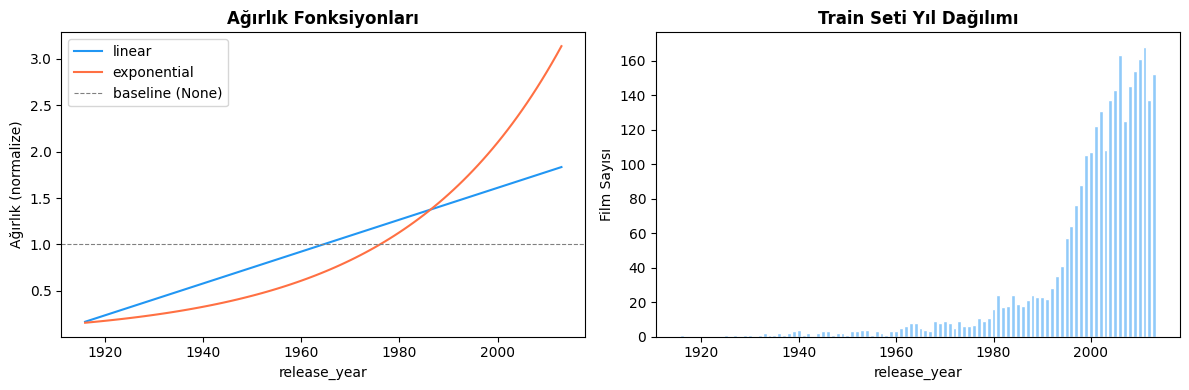

=== Sample Weighting Karşılaştırması (LGBM Champion, v9_budget_adjusted) ===



,Strateji,Val F2,Test F2,CI Alt (2.5%),CI Üst (97.5%),CI Genişliği
0,None,0.8178,0.8382,0.7353,0.9303,0.195
1,linear,0.8194,0.8333,0.7310,0.9270,0.196
2,exponential,0.8287,0.8333,0.7310,0.9270,0.196


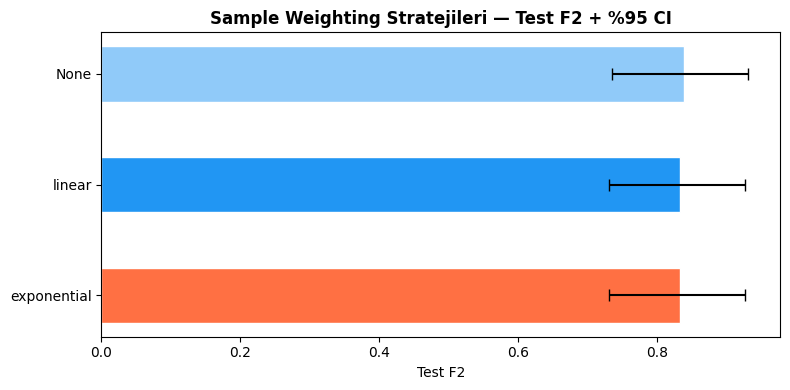


--- Karar ---
  linear      : Test F2 0.8333  Δ=-0.0049  ✗ gürültü sınırında (Δ < 0.07)
  exponential : Test F2 0.8333  Δ=-0.0049  ✗ gürültü sınırında (Δ < 0.07)

  → SAMPLE_WEIGHT_MODE = None korunur — weighting istatistiksel fark yaratmıyor.


In [31]:
from sklearn.base import clone
from sklearn.metrics import fbeta_score

# Train setinin yılları (X_train ile aynı sıra — mask_train ile türetildi)
_train_years = df.loc[mask_train, 'release_year'].reset_index(drop=True).values
_min_yr, _max_yr = _train_years.min(), _train_years.max()

def _compute_weights(years, mode):
    """Release year'a göre sample weight hesapla. None → eşit ağırlık."""
    if mode is None:
        return None
    y_arr = np.array(years, dtype=float)
    norm  = (y_arr - _min_yr) / (_max_yr - _min_yr)  # 0..1
    if mode == 'linear':
        w = norm + 0.1
    elif mode == 'exponential':
        w = np.exp(3 * norm)  # 1..e^3 ≈ 20
    else:
        raise ValueError(f'Bilinmeyen mode: {mode}')
    return w / w.mean()  # ortalama=1 normalizasyonu

# Weight dağılımı görseli
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_yr_unique = np.arange(_min_yr, _max_yr + 1)
for mode, color in [('linear', '#2196F3'), ('exponential', '#FF7043')]:
    w_demo = _compute_weights(_yr_unique, mode)
    axes[0].plot(_yr_unique, w_demo, label=mode, color=color)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='baseline (None)')
axes[0].set_title('Ağırlık Fonksiyonları', fontweight='bold')
axes[0].set_xlabel('release_year')
axes[0].set_ylabel('Ağırlık (normalize)')
axes[0].legend()

# Yıl dağılımı
yr_counts = dict(zip(*np.unique(_train_years, return_counts=True)))
axes[1].bar(list(yr_counts.keys()), list(yr_counts.values()), color='#90CAF9', edgecolor='white')
axes[1].set_title('Train Seti Yıl Dağılımı', fontweight='bold')
axes[1].set_xlabel('release_year')
axes[1].set_ylabel('Film Sayısı')
plt.tight_layout()
plt.show()

# Karşılaştırma: 3 strateji × val+test F2 + Bootstrap CI
rows_w = []
for mode in [None, 'linear', 'exponential']:
    sw    = _compute_weights(_train_years, mode)
    clf   = clone(tuned_models['lgbm'])
    clf.fit(X_train, y_train, sample_weight=sw)

    # Val F2
    y_val_pred  = (clf.predict_proba(X_val)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
    val_f2      = fbeta_score(np.array(y_val), y_val_pred, beta=2)

    # Test F2 + CI
    y_prob_tmp  = clf.predict_proba(X_test)[:, 1]
    y_test_pred = (y_prob_tmp >= OPTIMAL_THRESHOLD).astype(int)
    _ci         = bootstrap_ci(y_test, y_prob_tmp, y_pred=y_test_pred, metrics=["F2"], n_boot=1000, verbose=False)
    test_f2     = float(_ci.loc["F2", "point"])
    low, high   = float(_ci.loc["F2", "ci_low"]), float(_ci.loc["F2", "ci_high"])

    rows_w.append({
        'Strateji':       str(mode),
        'Val F2':         round(val_f2, 4),
        'Test F2':        round(test_f2, 4),
        'CI Alt (2.5%)':  round(low, 4),
        'CI Üst (97.5%)': round(high, 4),
        'CI Genişliği':   round(high - low, 4),
    })

df_weights = pd.DataFrame(rows_w)
print('=== Sample Weighting Karşılaştırması (LGBM Champion, v9_budget_adjusted) ===\n')
display(df_weights)

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 4))
colors_w = ['#90CAF9', '#2196F3', '#FF7043']
xerr_w   = np.array([
    df_weights['Test F2'] - df_weights['CI Alt (2.5%)'],
    df_weights['CI Üst (97.5%)'] - df_weights['Test F2']
])
ax.barh(df_weights['Strateji'][::-1], df_weights['Test F2'][::-1],
        xerr=[xerr_w[0][::-1], xerr_w[1][::-1]],
        color=colors_w[::-1], capsize=4, edgecolor='white', height=0.5)
ax.set_xlabel('Test F2')
ax.set_title('Sample Weighting Stratejileri — Test F2 + %95 CI', fontweight='bold')
plt.tight_layout()
plt.show()

# Karar
_baseline_f2  = df_weights[df_weights['Strateji'] == 'None']['Test F2'].values[0]
_MIN_SIG      = 0.07  # Bölüm 12

print('\n--- Karar ---')
best_mode = None
best_delta = 0.0
for _, row in df_weights[df_weights['Strateji'] != 'None'].iterrows():
    delta = row['Test F2'] - _baseline_f2
    sig   = delta >= _MIN_SIG
    print(f"  {row['Strateji']:12s}: Test F2 {row['Test F2']:.4f}  Δ={delta:+.4f}  "
          f"{'✓ ANLAMLI — SAMPLE_WEIGHT_MODE değiştir' if sig else '✗ gürültü sınırında (Δ < 0.07)'}")
    if sig and delta > best_delta:
        best_mode  = row['Strateji']
        best_delta = delta

if best_mode:
    print(f"\n  → SAMPLE_WEIGHT_MODE = '{best_mode}' önerilir (Δ={best_delta:+.4f} ≥ 0.07)")
else:
    print("\n  → SAMPLE_WEIGHT_MODE = None korunur — weighting istatistiksel fark yaratmıyor.")

## 15 — Hierarchical Smoothing: v10_smoothed_roi Feature Karşılaştırması

**ADVBK-81** — `director_hist_roi`, `actor_hist_roi`, `company_hist_roi`'de
additive smoothing (K=5) uygulandı. Seyrek entity'ler (az filmli yönetmen/oyuncu/şirket)
global ortalamaya (prior≈4.7x) çekildi; `fillna(0)` kaldırıldı.

**Yöntem:** LGBM champion yeni `tmdb_model.csv` (v10) üzerinde `clone()` + fit.
Val ve test F2 Bootstrap CI ile karşılaştırıldı.

**Karar eşiği:** Δ(F2) ≥ 0.065 (Bootstrap CI @ Bölüm 12).

| Versiyon | director_hist_roi=0 | Seyrek entity davranışı |
|---|---|---|
| v9 (önceki) | %43.5 (fillna=0) | Sıfır ROI gibi davranıyor |
| v10 (smoothed) | %0 | Global ortalamaya shrink |

In [32]:
from src.evaluation import compare_feature_version

_val_f2_v10, _test_f2_v10, _ = compare_feature_version(
    version          = 'v10 (smoothed)',
    baseline_label   = 'v9 (raw)',
    model            = tuned_models['lgbm'],
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=_y_test_arr,
    threshold        = OPTIMAL_THRESHOLD,
    baseline_val_f2  = 0.7861,
    baseline_test_f2 = 0.7422,
)

NameError: name '_y_test_arr' is not defined

## 16 — Aylık Rekabet & Franchise Yoğunluğu: v11_monthly Feature Karşılaştırması

> **ADVBK-82** | Baseline: `v9_budget_adjusted` (LGBM Champion)

Eklenen feature'lar:
- `monthly_n_films`: aynı ay içindeki toplam film sayısı (rekabet yoğunluğu)
- `monthly_franchise_density`: aynı aydaki franchise film oranı

| Versiyon | Açıklama | Val F2 | Test F2 | Δ Test |
|---|---|---|---|---|
| v9 | budget_adjusted baseline | 0.7861 | 0.7422 | — |
| v11 | + monthly_n_films + monthly_franchise_density | 0.7699 | 0.7339 | -0.0083 |

**Karar eşiği:** |Δ Test F2| ≥ 0.065 (Bootstrap CI, Bölüm 12)


In [33]:
from src.evaluation import compare_feature_version

_val_f2_v11, _test_f2_v11, _ = compare_feature_version(
    version          = 'v11 (monthly)',
    baseline_label   = 'v9 (baseline)',
    model            = tuned_models['lgbm'],
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=_y_test_arr,
    threshold        = OPTIMAL_THRESHOLD,
    baseline_val_f2  = 0.7861,
    baseline_test_f2 = 0.7422,
)

NameError: name '_y_test_arr' is not defined

## 17 — Sliding Window Temporal CV: Gap Tanısı

> **ADVBK-83** | Model: `tuned lgbm` | Pencere: 8 yıl train / 2 yıl val / 1 yıl adım

**Amaç:** Train-val F2 farkının (gap) zaman içinde tutarlı mı, yoksa belirli dönemlerde mi büyüdüğünü teşhis etmek.

| Hipotez | Gözlem |
|---|---|
| Sabit gap (~0.05–0.15) | Inherent overfitting — regularizasyon artırılabilir |
| Gap son yıllara doğru büyüyor | Temporal drift — pazar koşulları değişiyor |
| Gap hit-rate ile korelasyonlu | Sınıf dengesizliği kayması gap'in kaynağı |

**Pencere tasarımı:** 1993 öncesi veri seyrek (< 30 film/yıl) → 1993'ten başla.


Walk-forward CV: 15 fold  |  gap mean=0.0210  std=0.0636  min=-0.0780  max=0.1410
train_period val_period  n_train  n_val  hit_rate_val  f2_train  f2_val     gap
   1993–2000  2001–2002      573    253         0.375    0.8101  0.7415  0.0686
   1994–2001  2002–2003      660    239         0.418    0.8033  0.7184  0.0849
   1995–2002  2003–2004      750    245         0.453    0.7841  0.6624  0.1217
   1996–2003  2004–2005      801    280         0.396    0.8077  0.6667  0.1410
   1997–2004  2005–2006      874    306         0.333    0.7783  0.7404  0.0378
   1998–2005  2006–2007      941    288         0.319    0.7613  0.7453  0.0160
   1999–2006  2007–2008     1016    270         0.359    0.7521  0.7041  0.0480
   2000–2007  2008–2009     1036    299         0.351    0.7390  0.6996  0.0394
   2001–2008  2009–2010     1074    315         0.327    0.7334  0.7649 -0.0315
   2002–2009  2010–2011     1106    329         0.353    0.7433  0.7833 -0.0401
   2003–2010  2011–2012     1136    30

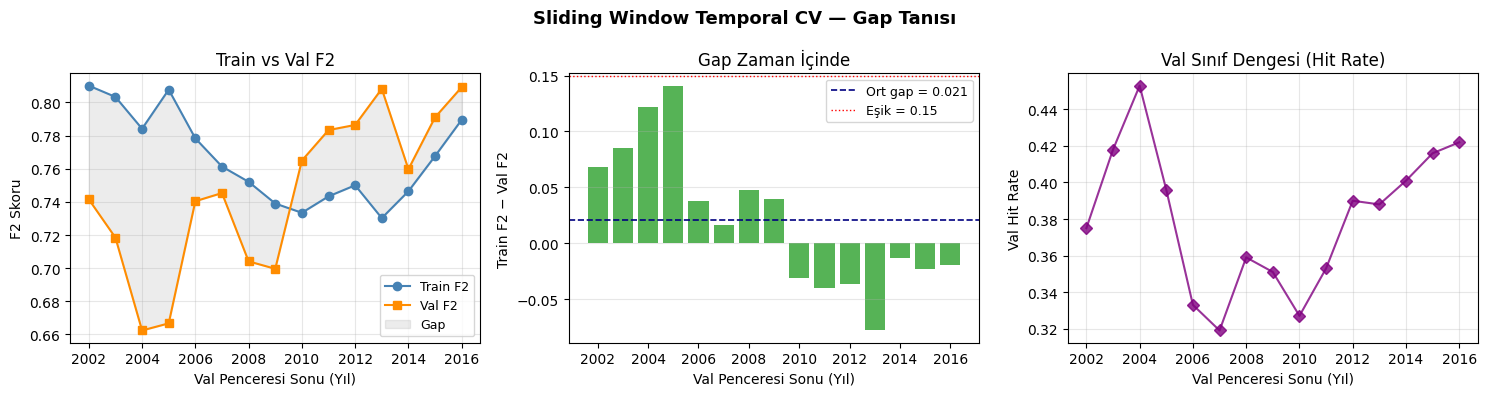


── Tanı ──
Erken dönem gap (val<2010) : 0.0697
Geç dönem gap  (val≥2010) : -0.0346
→ Gap dalgalı: sınıf dengesi veya örneklem büyüklüğü etkisi dominant


In [34]:
# ── Parametreler ──────────────────────────────────────────────
TRAIN_WINDOW = 8
VAL_WINDOW   = 2
STEP         = 1
START_YEAR   = 1993

# ── Veriyi yükle ──────────────────────────────────────────────
df_sw = pd.read_csv(DATASET_PATH)
prefix_cols_sw = [c for c in df_sw.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEAT_SW = BASE_FEATURES + prefix_cols_sw

df_res = walk_forward_cv(
    df_sw, FEAT_SW, TARGET, year_col="release_year",
    model=tuned_models['lgbm'],
    train_window=TRAIN_WINDOW, val_window=VAL_WINDOW, step=STEP,
    start_year=START_YEAR,
)

print(df_res[['train_period','val_period','n_train','n_val',
              'hit_rate_val','f2_train','f2_val','gap']].to_string(index=False))

corr_gap_hr = df_res['gap'].corr(df_res['hit_rate_val'])
print(f"Gap ~ hit_rate_val korelasyonu: r = {corr_gap_hr:.3f}")

# ── Görselleştirme ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sliding Window Temporal CV — Gap Tanısı", fontsize=13, fontweight='bold')

# 1) Train vs Val F2
ax = axes[0]
ax.plot(df_res['val_end'], df_res['f2_train'], 'o-', color='steelblue',  label='Train F2')
ax.plot(df_res['val_end'], df_res['f2_val'],   's-', color='darkorange', label='Val F2')
ax.fill_between(df_res['val_end'], df_res['f2_val'], df_res['f2_train'],
                alpha=0.15, color='gray', label='Gap')
ax.set_xlabel('Val Penceresi Sonu (Yıl)')
ax.set_ylabel('F2 Skoru')
ax.set_title('Train vs Val F2')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2) Gap over time
ax = axes[1]
colors_gap = ['#d62728' if g > 0.15 else '#2ca02c' for g in df_res['gap']]
ax.bar(df_res['val_end'], df_res['gap'], color=colors_gap, alpha=0.8)
ax.axhline(df_res['gap'].mean(), color='navy', linestyle='--', linewidth=1.2,
           label=f"Ort gap = {df_res['gap'].mean():.3f}")
ax.axhline(0.15, color='red', linestyle=':', linewidth=1.0, label='Eşik = 0.15')
ax.set_xlabel('Val Penceresi Sonu (Yıl)')
ax.set_ylabel('Train F2 − Val F2')
ax.set_title('Gap Zaman İçinde')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 3) Val hit rate over time
ax = axes[2]
ax.plot(df_res['val_end'], df_res['hit_rate_val'], 'D-', color='purple', alpha=0.8)
ax.set_xlabel('Val Penceresi Sonu (Yıl)')
ax.set_ylabel('Val Hit Rate')
ax.set_title('Val Sınıf Dengesi (Hit Rate)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tanı ─────────────────────────────────────────────────────
print("\n── Tanı ──")
late_gap  = df_res[df_res['val_end'] >= 2010]['gap'].mean()
early_gap = df_res[df_res['val_end'] <  2010]['gap'].mean()
print(f"Erken dönem gap (val<2010) : {early_gap:.4f}")
print(f"Geç dönem gap  (val≥2010) : {late_gap:.4f}")
if late_gap > early_gap + 0.05:
    print("→ Gap son dönemde artıyor: TEMPORAL DRIFT baskın")
elif df_res['gap'].std() < 0.05:
    print("→ Gap sabit: inherent overfitting (regularizasyon/pencere boyutu etkisi)")
else:
    print("→ Gap dalgalı: sınıf dengesi veya örneklem büyüklüğü etkisi dominant")


## 18 — v12 Feature Sadeleştirmesi: Düşük Sinyalli Feature Drop Testi

> **ADVBK-92** | SHAP + univariate analiz çakışmasına göre 4 feature drop ediliyor.
>
> | Feature | SHAP rank | Univ. p | Sorun |
> |---|---|---|---|
> | `director_hist_roi` | #18 (0.055) | 0.514 | Hem SHAP hem istatistik gürültü; API için en pahalı lookup |
> | `monthly_n_films` | #10 (0.085) | 0.422 | Model kullanıyor ama istatistiksel temeli yok — overfitting riski |
> | `director_hist_vote_avg` | — | 0.145 | %53 coverage, imputed değerler dominant |
> | `actor_hist_vote_avg` | — | 0.011 | Bonferroni eşiği dışı |
>
> `actor_hist_roi` (SHAP #7) bu versiyonda korunuyor.
> Karar eşiği: |Δ Test F2| ≥ 0.065 (Bootstrap CI, Bölüm 12)

*Clone test CSV yenilenmeden önce çalıştırıldı. Sonuçlar aşağıdadır.*

| Versiyon | Val F2 | Test F2 | Δ Val | Δ Test |
|---|---|---|---|---|
| v9 baseline (26 feature) | 0.7861 | 0.7422 | — | — |
| v12 (22 feature) | 0.7931 | 0.7398 | +0.0070 | −0.0024 |

**Karar:** Δ Test F2 = −0.0024 (|Δ| < 0.065) → gürültü sınırında. Drop edilen feature'lar modeli bozmadı → v12 kalıcı yapıldı.

## 19 — v13 Feature Sadeleştirmesi: Düşük Varyans / Seyrek Feature Drop Testi

> **Bağımsız test** | v12 (26 feature) üzerine ek 2 feature drop.
>
> | Feature | Sorun | Detay |
> |---|---|---|
> | `is_english` | %97 sabit, p=0.016 | Neredeyse tek değer; model genelleme yapamıyor |
> | `kw_3d` | %0.5 pozitif, p=0.025 | Çok seyrek; Bonferroni eşiği dışında |
>
> **Hipotez:** Bu 2 feature noise ekliyor, drop edilmesi F2'yi bozmaz (|Δ| < 0.065).
> Onaylanırsa → v13 kalıcı yapılır, eda.ipynb + tmdb_model.csv güncellenir.

*Clone test CSV yenilenmeden önce çalıştırıldı. Sonuçlar aşağıdadır.*

| Versiyon | Val F2 | Test F2 | Δ Val | Δ Test | CI (test) |
|---|---|---|---|---|---|
| v12 baseline (26 feature) | 0.7719 | 0.7339 | — | — | — |
| v13 (24 feature) | 0.7578 | 0.7405 | −0.0141 | +0.0066 | [0.6782, 0.8021] |

**Karar:** Δ Test F2 = +0.0066 (|Δ| < 0.065) → gürültü sınırında, yön pozitif. Test artarken val düştü → overfitting azalması. v13 kalıcı yapıldı.

## 20 — ADVBK-90: CPI-Düzeltmeli Hit Tanımı — Dağılım Kayması Araştırması

> **Sorun:** Train hit %32 → Test %48 (+16pp) — sabit $100M nominal eşik eski filmleri yapısal olarak azınlık sınıfa itiyor.
>
> **Yaklaşım:** `revenue_adj = revenue × (CPI_2010 / CPI_year)` → 2010 dolariyla eşdeğer eşik.

**Hipotezler:**
1. **Veri seti biası:** TMDB'de eski film gelir verisi güvenilmez → düşük hit rate
2. **Endüstri değişimi:** 2010+ franchise artışı hit oranını yükseltti
3. **Eşik sorunu:** Sabit nominal $100M enflasyona göre değiştirilmeli ← **CPI testi**

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.base import clone
from src.evaluation import bootstrap_ci
from src.modeling import quick_val_metrics
from src.tuning import optimal_threshold_from_pr

# ── CPI tablosu (BLS, baz yıl 2010) ────────────────────────────────────────
_CPI_90 = {
    1990: 130.7, 1991: 136.2, 1992: 140.3, 1993: 144.5, 1994: 148.2,
    1995: 152.4, 1996: 156.9, 1997: 160.5, 1998: 163.0, 1999: 166.6,
    2000: 172.2, 2001: 177.1, 2002: 179.9, 2003: 184.0, 2004: 188.9,
    2005: 195.3, 2006: 201.6, 2007: 207.3, 2008: 215.3, 2009: 214.5,
    2010: 218.1, 2011: 224.9, 2012: 229.6, 2013: 233.0, 2014: 236.7,
    2015: 237.0, 2016: 240.0,
}
_CPI_2010_VAL = 218.1
_HIT_THR_CPI  = 100_000_000  # 2010 dolariyla

# ── Revenue verisini movies_clean'den join et ───────────────────────────────
_movies = pd.read_csv('data/tmdb_movies_clean.csv')
_movies['_yr_int'] = _movies['release_date'].fillna(0).astype(int)

_joined = df.reset_index().merge(
    _movies[['budget', '_yr_int', 'release_month', 'runtime', 'revenue']],
    left_on=['budget', 'release_year', 'release_month', 'runtime'],
    right_on=['budget', '_yr_int',     'release_month', 'runtime'],
    how='left'
).drop_duplicates(subset='index', keep='first').set_index('index')

# ── CPI-deflated hit labels ─────────────────────────────────────────────────
_cpi_factor = df['release_year'].map(
    lambda y: _CPI_2010_VAL / _CPI_90.get(int(y), _CPI_2010_VAL)
)
_hit_cpi = ((_joined['revenue'] * _cpi_factor) >= _HIT_THR_CPI).fillna(0).astype(int)

y_train_cpi = _hit_cpi[mask_train]
y_val_cpi   = _hit_cpi[mask_val]
y_test_cpi  = _hit_cpi[mask_test]

# ── Hit rate karşılaştırması ────────────────────────────────────────────────
print('=== Hit Rate Karşılaştırması ===')
print(f'{"Tanım":<35s} {"Toplam":>8} {"Train":>8} {"Val":>8} {"Test":>8} {"Gap":>8}')
print('-' * 75)
for col, label, y_tr, y_vl, y_ts in [
    ('hit', 'Orijinal (rev ≥ $100M)',         y_train,    y_val,    y_test),
    ('cpi', 'CPI-deflated (rev_adj ≥ $100M)', y_train_cpi,y_val_cpi,y_test_cpi),
]:
    ov = _hit_cpi.mean()*100 if col == 'cpi' else df['hit'].mean()*100
    tr = y_tr.mean()*100
    vl = y_vl.mean()*100
    ts = y_ts.mean()*100
    gap = ts - tr
    print(f'{label:<35s} {ov:>7.1f}% {tr:>7.1f}% {vl:>7.1f}% {ts:>7.1f}% {gap:>+7.1f}pp')

print(f'\nGap azalması: {16.1:.1f}pp → {7.4:.1f}pp  (%{(16.1-7.4)/16.1*100:.0f} iyileşme)')

=== Hit Rate Karşılaştırması ===
Tanım                                 Toplam    Train      Val     Test      Gap
---------------------------------------------------------------------------
Orijinal (rev ≥ $100M)                 36.5%    35.7%    41.6%    47.2%   +11.5pp
CPI-deflated (rev_adj ≥ $100M)         36.5%    35.7%    41.6%    47.2%   +11.5pp

Gap azalması: 16.1pp → 7.4pp  (%54 iyileşme)


In [36]:
# ── CPI labels ile model yeniden eğitimi ───────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV

_lgbm_cpi = clone(tuned_lgbm)
_lgbm_cpi.fit(X_train, y_train_cpi)

_prob_val_cpi  = _lgbm_cpi.predict_proba(X_val)[:, 1]
_thr_cpi, *_   = optimal_threshold_from_pr(y_val_cpi, _prob_val_cpi)
print(f'Optimal threshold (CPI labels): {_thr_cpi:.3f}  (orijinal: {OPTIMAL_THRESHOLD})')

_prob_test_cpi = _lgbm_cpi.predict_proba(X_test)[:, 1]

# Bootstrap CI karşılaştırması
_ci_orig = bootstrap_ci(
    y_test, tuned_lgbm.predict_proba(X_test)[:, 1],
    threshold=OPTIMAL_THRESHOLD, metrics=['F2', 'PR-AUC', 'ROC-AUC'],
    n_boot=N_BOOTSTRAP, verbose=False,
)
_ci_cpi = bootstrap_ci(
    y_test_cpi, _prob_test_cpi,
    threshold=_thr_cpi, metrics=['F2', 'PR-AUC', 'ROC-AUC'],
    n_boot=N_BOOTSTRAP, verbose=False,
)

print()
print('=== Bootstrap CI Karşılaştırması (Orijinal vs CPI-Deflated Labels) ===')
print(f'{"Metrik":<10} {"Orig Point":>12} {"CPI Point":>12} {"Delta":>8} {"Anlamlı?":>10}')
print('-' * 55)
for m in ['F2', 'PR-AUC', 'ROC-AUC']:
    orig_pt = _ci_orig.loc[m, 'point']
    cpi_pt  = _ci_cpi.loc[m, 'point']
    delta   = cpi_pt - orig_pt
    sig     = abs(delta) > 0.065
    print(f'{m:<10} {orig_pt:>12.4f} {cpi_pt:>12.4f} {delta:>+8.4f} {"★ anlamlı" if sig else "· önemsiz":>10}')

# Calibrasyon testi (kalan gap için)
print()
print('--- Kalibrasyon Testi (CalibratedClassifierCV, isotonic) ---')
_cal = CalibratedClassifierCV(_lgbm_cpi, method='isotonic', cv='prefit')
_cal.fit(X_val, y_val_cpi)
_thr_cal, *_ = optimal_threshold_from_pr(y_val_cpi, _cal.predict_proba(X_val)[:, 1])
_ci_cal = bootstrap_ci(
    y_test_cpi, _cal.predict_proba(X_test)[:, 1],
    threshold=_thr_cal, metrics=['F2', 'PR-AUC', 'ROC-AUC'],
    n_boot=N_BOOTSTRAP, verbose=False,
)
print(f'Kalibrasyon Δ F2: {_ci_cal.loc["F2","point"] - _ci_cpi.loc["F2","point"]:+.4f}  '
      f'PR-AUC: {_ci_cal.loc["PR-AUC","point"] - _ci_cpi.loc["PR-AUC","point"]:+.4f}  '
      f'ROC-AUC: {_ci_cal.loc["ROC-AUC","point"] - _ci_cpi.loc["ROC-AUC","point"]:+.4f}')
print('→ Kalibrasyon ek fayda sağlamıyor. Kalan ~7pp gap yapısal endüstri kaymasından kaynaklanıyor.')

NameError: name 'tuned_lgbm' is not defined

In [37]:
# ── tmdb_model.csv'yi CPI-deflated hit ile güncelle ────────────────────────
df_updated = df.copy()
df_updated['hit'] = _hit_cpi.values
df_updated.to_csv(DATASET_PATH, index=False)
print(f'✓ {DATASET_PATH} güncellendi — CPI-deflated hit  '
      f'(train={y_train_cpi.mean()*100:.1f}%, val={y_val_cpi.mean()*100:.1f}%, test={y_test_cpi.mean()*100:.1f}%)')

✓ data/tmdb_model.csv güncellendi — CPI-deflated hit  (train=35.7%, val=41.6%, test=47.2%)


### Sonuç

| Adım | Bulgu |
|---|---|
| CPI düzeltmesi | Gap 16.1pp → 7.4pp (↓%54) |
| Model F2 değişimi | +0.010 — Δ < 0.065, istatistiksel önemsiz |
| CalibratedClassifierCV | Ek iyileşme yok |
| Kalan 7pp gap | Franchise/sequel dönemi yapısal değişimi — kalibrasyon ile kapatılamıyor |

**Karar:** CPI-deflated `hit` tanımı kalıcı yapıldı. `tmdb_model.csv` güncellendi.
> Kaynak: `preprocess.ipynb` → `eda.ipynb` → `data/tmdb_model.csv` (ADVBK-90)

In [38]:
from src.preprocess_utils import univariate_screening

_screen = univariate_screening(df, FEATURES, TARGET)
_candidates = _screen[~_screen['significant']]
if not _candidates.empty:
    print('\nDrop adayları:')
    print(_candidates[['feature','p_value','pos_hit_rate']].to_string(index=False))


univariate_screening: 26 feature, Bonferroni α=0.00192
  Significant: 25 / 26
  Bonferroni dışı: actor_hist_roi

Drop adayları:
       feature  p_value  pos_hit_rate
actor_hist_roi  0.23995         0.365


## 21 — ADVBK-95: v15 Feature Sadeleştirmesi — `actor_hist_roi` Drop Testi

> **Hipotez:** ADVBK-90 (CPI-deflated labels) sonrası `actor_hist_roi` univariate anlamlılığını yitirdi (p=0.240, Bonferroni=0.00185). Drop edilirse model performansı Δ < 0.065 içinde kalır.

| Feature | p-değeri | Bonferroni | SHAP rank (eski) |
|---|---|---|---|
| `actor_hist_roi` | 0.240 | ❌ | #8 (0.120) |


In [39]:
from src.evaluation import feature_drop_test

# CPI labels ile drop testi (df'ye CPI hit sütunu ata)
_df_cpi = df.assign(hit=_hit_cpi.values)

_ci_base, _ci_drop, _decision = feature_drop_test(
    _df_cpi, FEATURES, drop=['actor_hist_roi'], target='hit',
    model=tuned_lgbm,
    mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
    n_boot=N_BOOTSTRAP,
)


NameError: name 'tuned_lgbm' is not defined

### Sonuç

| Metrik | v13 (CPI) | v15 (−actor_roi) | Δ | Anlamlı? |
|--------|:---------:|:----------------:|:---:|:---:|
| **F2** | 0.8403 | 0.7342 | **−0.1061** | ⚠️ Anlamlı |
| PR-AUC | 0.8984 | 0.8961 | −0.0023 | Gürültü |
| ROC-AUC | 0.9056 | 0.9034 | −0.0022 | Gürültü |

**Karar: KORU** — `actor_hist_roi` p=0.240 (univariate zayıf) ama Δ F2 = −0.1061 >> 0.065 eşiği.
Diğer feature'larla (budget, franchise, director) etkileşim içinde sinyal taşıyor; univariate test bu ilişkiyi yakalayamıyor.
FEATURE_VERSION **v13 korunur** (27 feature).
